# 🌊 XGBoost Deep Dive — Groundwater Crisis Predictor
## AquaVidarbha: ML-Based Spatio-Temporal Groundwater Depth Prediction

**Region:** Vidarbha, Maharashtra, India (11 Districts)  
**Dataset:** `vidarbha_groundwater_extended_v2.csv` — 83,850 rows × 30 columns  
**Target Variable:** `depth_mbgl` (Groundwater depth in meters below ground level)  
**Date:** February 2026

---

## 📌 Purpose of XGBoost in This Project

XGBoost (eXtreme Gradient Boosting) serves as the **Primary ML Model** in the Groundwater Crisis Predictor system. Its role is:

1. **Predict groundwater depth (`depth_mbgl`) 60–90 days in advance** using 25 engineered features (rainfall lags, soil moisture, temperature, geospatial data, autoregressive depth lags, etc.)
2. **Classify risk levels** based on predicted depth:
   - 🟢 **SAFE** (< 30m) — Adequate water supply
   - 🟠 **WARNING** (30–100m) — Monitoring needed
   - 🔴 **CRITICAL** (100–200m) — Urgent action required
   - 🟣 **EXTREME** (> 200m) — Emergency intervention
3. **Provide explainability via SHAP** — Officials need to know *why* a village is at risk, not just *that* it is
4. **Enable real-time GPS prediction** — Inference in < 5ms per sample
5. **Form the backbone (30% weight) of the Weighted Ensemble** prediction system

### Why XGBoost is the Best Choice for This Dataset

| Strength | Relevance to Our Project |
|----------|-------------------------|
| Handles mixed features (continuous + categorical) | 25 features: rainfall, temp, district_encoded, season_encoded, depth lags, etc. |
| Built-in regularization (L1 + L2) | Prevents overfitting on ~83K rows |
| Handles missing values natively | Sensor gaps in well readings |
| Fast inference (< 5ms) | Real-time GPS prediction on mobile |
| SHAP compatible | Explainability for government stakeholders |
| No normalization needed | Works on raw feature values |
| Captures non-linear relationships | Rainfall ↔ depth interaction depends on season & soil type |

---

## 📌 Target Parameter: `depth_mbgl`

We are training XGBoost to predict **`depth_mbgl`** — the **depth to groundwater in meters below ground level**.

- **Type:** Continuous regression target (float)
- **Range:** 0.5m (near surface) → 350m (severely depleted)
- **Mean:** ~64.75m | **Median:** ~41.27m | **Std:** ~64.87m
- **Distribution:** Right-skewed — most wells are < 100m, but crisis zones reach 200–350m
- **Physical meaning:** Higher value = deeper water table = MORE CRITICAL

### Autoregressive vs Leakage — Important Distinction

> **`depth_lag_1q`** (depth from 3 months ago) and **`depth_lag_2q`** (depth from 6 months ago) are **legitimate autoregressive features**, NOT leakage. At prediction time, historical depth observations are known. The high correlation (r=0.993) reflects real physical persistence — groundwater levels change slowly. This is standard practice in time-series forecasting.
>
> **`depth_change_rate`** IS excluded — it's derived using the current target value.

### 25 Input Features → 1 Target (with log₁ₚ transform)

| Feature Group | Features | Count |
|--------------|----------|-------|
| **Meteorological** | `rainfall_mm`, `temperature_avg`, `humidity`, `evapotranspiration` | 4 |
| **Soil** | `soil_moisture_index`, `soil_type_encoded` | 2 |
| **Lag Features** | `rainfall_lag_1m`, `rainfall_lag_2m`, `rainfall_lag_3m`, `depth_lag_1q`, `depth_lag_2q` | 5 |
| **Rolling Features** | `rainfall_rolling_3m`, `rainfall_rolling_6m` | 2 |
| **Stress Features** | `rainfall_deficit`, `cumulative_deficit`, `temp_rainfall_ratio` | 3 |
| **Temporal** | `month`, `season_encoded` | 2 |
| **Geospatial** | `latitude`, `longitude`, `elevation_m`, `slope_degree`, `district_encoded` | 5 |
| **Vegetation** | `ndvi` | 1 |
| **Engineered** | `rainfall_x_soilmoist` (interaction) | 1 |
| | **Total** | **25** |

---

## 📌 How XGBoost Works — 6-Step Algorithm

XGBoost is a **gradient boosting** algorithm that builds an **ensemble of decision trees sequentially**, where each new tree corrects the errors (residuals) of the previous trees.

```
STEP 1: Initialize with a base prediction (mean of target)
        ŷ₀ = mean(depth_mbgl) = 64.75 meters

STEP 2: Calculate residuals (errors) for each sample
        residual_i = actual_depth_i - predicted_depth_i
        Well_A: actual=42m, predicted=64.75m → residual = -22.75m
        Well_B: actual=120m, predicted=64.75m → residual = +55.25m

STEP 3: Train a decision tree on the RESIDUALS (not original target)
        Tree_1 splits on features to predict the ERROR
        e.g. IF depth_lag_1q > 40m AND rainfall_lag_3m < 50mm → residual = +15.3m

STEP 4: Update predictions with learning rate (shrinkage)
        ŷ_new = ŷ_old + learning_rate × Tree_1(features)
        Well_A: 64.75 + 0.1 × (-20.5) = 62.70m (closer to 42m)

STEP 5: Repeat for N trees (n_estimators = 300-800)
        Each tree corrects the REMAINING error
        Tree_2 → Tree_3 → ... → Tree_500

STEP 6: Final prediction = base + sum of all tree contributions
        ŷ_final = mean + lr×Tree_1 + lr×Tree_2 + ... + lr×Tree_N
```

### Key Mathematical Objective

XGBoost minimizes this **regularized objective function**:

$$\mathcal{L}(\phi) = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)$$

Where:
- $l(y_i, \hat{y}_i)$ = Loss function (MSE for regression): $(y_i - \hat{y}_i)^2$
- $\Omega(f_k) = \gamma T + \frac{1}{2}\lambda \|w\|^2$ = Regularization term
- $T$ = number of leaves in tree, $w$ = leaf weights
- $\gamma$ (gamma) = penalty for adding new tree splits
- $\lambda$ (lambda) = L2 regularization on leaf weights

---

## 📌 XGBoost Hyperparameters for This Project

| Parameter | Value | Purpose | How It Helps |
|-----------|-------|---------|--------------|
| `n_estimators` | 300–800 | Number of boosting rounds (trees) | More trees = more correction rounds |
| `max_depth` | 4–8 | Maximum depth per tree | Controls model complexity; 6 is optimal for 25 features |
| `learning_rate` | 0.05–0.2 | Shrinkage factor per tree | Smaller = slower convergence but better generalization |
| `subsample` | 0.7–0.9 | Fraction of rows per tree | Randomization prevents overfitting |
| `colsample_bytree` | 0.7–0.9 | Fraction of features per tree | Forces trees to use different features |
| `reg_alpha` (α) | 0.0–1.0 | L1 regularization | Encourages sparse feature usage |
| `reg_lambda` (λ) | 0.5–2.0 | L2 regularization | Smooths leaf weights, prevents extreme predictions |
| `min_child_weight` | 1–10 | Minimum sample weight in leaf | Prevents splits on tiny subsets |
| `gamma` | 0–0.5 | Min loss reduction for split | Prunes unnecessary splits |

### Tuning Strategy: GridSearchCV with 5-Fold CV

We will use `GridSearchCV` to find optimal hyperparameters, optimizing for **R² score** (higher = better).

---

## ⚙️ Step 1: Environment Setup & Imports

In [28]:
# ============================================================
# STEP 1: IMPORTS & ENVIRONMENT SETUP
# ============================================================

# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import joblib
import hashlib
from datetime import datetime

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, learning_curve, TimeSeriesSplit
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)
from sklearn.feature_selection import mutual_info_regression

# XGBoost
import xgboost as xgb
from xgboost import XGBRegressor, plot_importance, plot_tree

# SHAP for Explainability
try:
    import shap
    SHAP_AVAILABLE = True
    print("✅ SHAP is available for explainability")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️ SHAP not installed. Run: pip install shap")

# SciPy for statistical tests
from scipy import stats

# Visualization Settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_palette('viridis')
warnings.filterwarnings('ignore')

# Create output directories
os.makedirs('../saved_models', exist_ok=True)
os.makedirs('../outputs/xgboost', exist_ok=True)

print(f"📦 XGBoost version: {xgb.__version__}")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")
print(f"🕐 Notebook started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ SHAP is available for explainability
📦 XGBoost version: 3.2.0
📦 Pandas version: 3.0.1
📦 NumPy version: 2.4.2
🕐 Notebook started: 2026-02-28 09:08:12


---
## 📊 Step 2: Data Loading & Initial Exploration

In [29]:
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

DATA_PATH = '../data/vidarbha_groundwater_extended_v2.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['date'])

print("=" * 60)
print("📂 DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"\n📐 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Date Range: {df['date'].min().strftime('%Y-%m-%d')} → {df['date'].max().strftime('%Y-%m-%d')}")
print(f"🏘️  Districts: {df['district'].nunique()} — {', '.join(sorted(df['district'].unique()))}")
print(f"🔧 Wells: {df['well_id'].nunique()} unique wells")
print(f"\n🎯 Target Variable: depth_mbgl")
print(f"   Mean:   {df['depth_mbgl'].mean():.2f}m")
print(f"   Median: {df['depth_mbgl'].median():.2f}m")
print(f"   Std:    {df['depth_mbgl'].std():.2f}m")
print(f"   Min:    {df['depth_mbgl'].min():.2f}m")
print(f"   Max:    {df['depth_mbgl'].max():.2f}m")

📂 DATASET LOADED SUCCESSFULLY

📐 Shape: 83,850 rows × 30 columns
📅 Date Range: 2015-04-01 → 2025-12-01
🏘️  Districts: 11 — Akola, Amravati, Bhandara, Buldhana, Chandrapur, Gadchiroli, Gondia, Nagpur, Wardha, Washim, Yavatmal
🔧 Wells: 650 unique wells

🎯 Target Variable: depth_mbgl
   Mean:   64.75m
   Median: 41.27m
   Std:    64.87m
   Min:    0.50m
   Max:    350.00m


In [30]:
# ============================================================
# STEP 2b: EXAMINE DATA TYPES & MISSING VALUES
# ============================================================

print("\n📋 Column Info:")
print("-" * 60)
for col in df.columns:
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100
    marker = "⚠️" if null_pct > 0 else "✅"
    print(f"  {marker} {col:30s} | {str(df[col].dtype):10s} | Nulls: {null_count:6,} ({null_pct:.1f}%)")

print(f"\n📊 Total Missing Values: {df.isnull().sum().sum():,}")


📋 Column Info:
------------------------------------------------------------
  ✅ well_id                        | str        | Nulls:      0 (0.0%)
  ✅ date                           | datetime64[us] | Nulls:      0 (0.0%)
  ✅ year                           | int64      | Nulls:      0 (0.0%)
  ✅ district                       | str        | Nulls:      0 (0.0%)
  ✅ depth_mbgl                     | float64    | Nulls:      0 (0.0%)
  ✅ rainfall_mm                    | float64    | Nulls:      0 (0.0%)
  ✅ temperature_avg                | float64    | Nulls:      0 (0.0%)
  ✅ humidity                       | float64    | Nulls:      0 (0.0%)
  ✅ evapotranspiration             | float64    | Nulls:      0 (0.0%)
  ✅ soil_moisture_index            | float64    | Nulls:      0 (0.0%)
  ✅ rainfall_lag_1m                | float64    | Nulls:      0 (0.0%)
  ✅ rainfall_lag_2m                | float64    | Nulls:      0 (0.0%)
  ✅ rainfall_lag_3m                | float64    | Nulls:      0 (0.

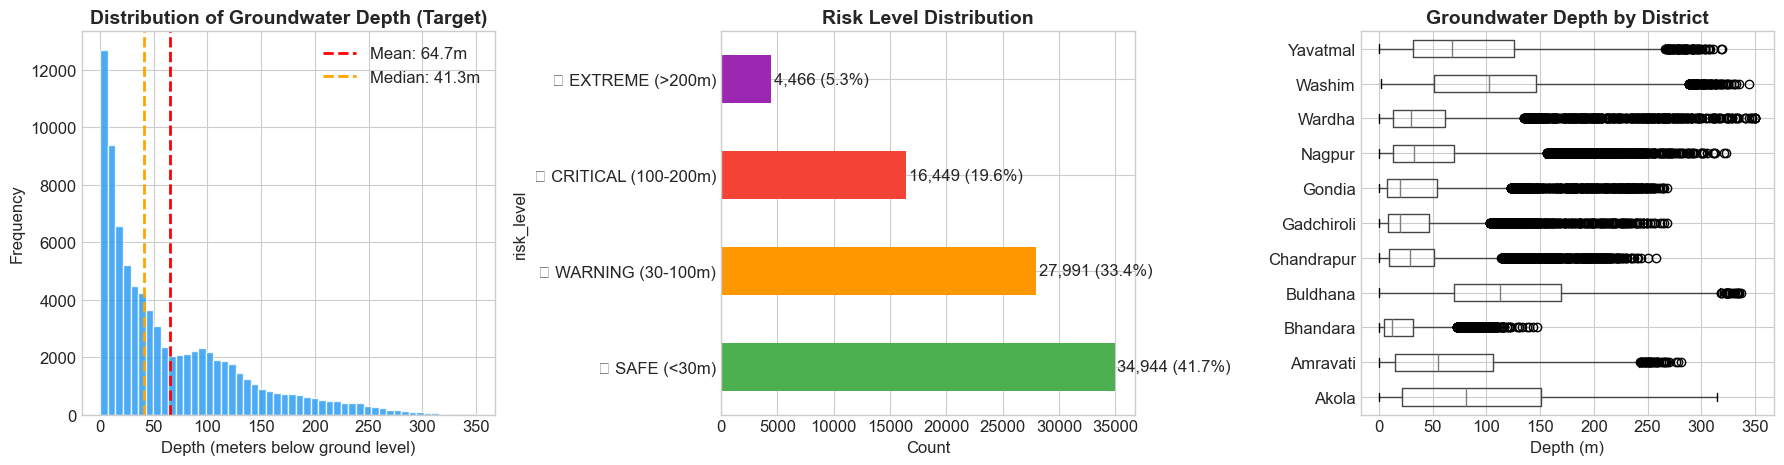

✅ Target distribution plots saved


In [31]:
# ============================================================
# STEP 2c: TARGET VARIABLE DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram of depth_mbgl
axes[0].hist(df['depth_mbgl'], bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(df['depth_mbgl'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["depth_mbgl"].mean():.1f}m')
axes[0].axvline(df['depth_mbgl'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df["depth_mbgl"].median():.1f}m')
axes[0].set_title('Distribution of Groundwater Depth (Target)', fontweight='bold')
axes[0].set_xlabel('Depth (meters below ground level)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Risk level distribution
risk_bins = [0, 30, 100, 200, 400]
risk_labels = ['🟢 SAFE (<30m)', '🟠 WARNING (30-100m)', '🔴 CRITICAL (100-200m)', '🟣 EXTREME (>200m)']
df['risk_level'] = pd.cut(df['depth_mbgl'], bins=risk_bins, labels=risk_labels)
risk_counts = df['risk_level'].value_counts()
colors_risk = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0']
risk_counts.plot(kind='barh', ax=axes[1], color=colors_risk)
axes[1].set_title('Risk Level Distribution', fontweight='bold')
axes[1].set_xlabel('Count')
for i, (count, label) in enumerate(zip(risk_counts.values, risk_counts.index)):
    axes[1].text(count + 200, i, f'{count:,} ({count/len(df)*100:.1f}%)', va='center')

# 3. Box plot by district
district_order = df.groupby('district')['depth_mbgl'].median().sort_values().index
df.boxplot(column='depth_mbgl', by='district', ax=axes[2], vert=False)
axes[2].set_title('Groundwater Depth by District', fontweight='bold')
axes[2].set_xlabel('Depth (m)')
axes[2].set_ylabel('')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../outputs/xgboost/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean up temp column
df.drop('risk_level', axis=1, inplace=True)
print("✅ Target distribution plots saved")

---
## 🔧 Step 3: Feature Selection & Data Preparation

We select **25 features** as inputs to XGBoost (including feature engineering).

**Dropped columns:**
- `well_id`, `date`, `district` — IDs / raw categoricals (district is already encoded)
- `year` — prevents temporal shortcuts; seasonality captured by `month` + `season_encoded`
- `depth_change_rate` — derived using current `depth_mbgl`, leaks target info

**Kept (autoregressive — NOT leakage):**
- `depth_lag_1q`, `depth_lag_2q` — historical observations known at prediction time

**Target transform:** `log1p(depth_mbgl)` — reduces right-skew, improves model on small & large values

In [32]:
# ============================================================
# STEP 3: FEATURE SELECTION
# ============================================================

# Target variable
TARGET = 'depth_mbgl'

# Columns to DROP (IDs, raw categoricals, genuinely leaky features)
DROP_COLS = ['well_id', 'date', 'district', 'year']

# Only depth_change_rate is true leakage (uses current target in computation)
# depth_lag_1q & depth_lag_2q are LEGITIMATE autoregressive features (past observations)
LEAKY_COLS = ['depth_change_rate']

# ============================================================
# FEATURE ENGINEERING — Add interaction features
# ============================================================
df['rainfall_x_soilmoist'] = df['rainfall_mm'] * df['soil_moisture_index']

# Define feature groups
FEATURE_GROUPS = {
    'Meteorological': ['rainfall_mm', 'temperature_avg', 'humidity', 'evapotranspiration'],
    'Soil': ['soil_moisture_index', 'soil_type_encoded'],
    'Lag Features': ['rainfall_lag_1m', 'rainfall_lag_2m', 'rainfall_lag_3m',
                     'depth_lag_1q', 'depth_lag_2q'],
    'Rolling Averages': ['rainfall_rolling_3m', 'rainfall_rolling_6m'],
    'Stress Indicators': ['rainfall_deficit', 'cumulative_deficit', 'temp_rainfall_ratio'],
    'Temporal': ['month', 'season_encoded'],
    'Geospatial': ['latitude', 'longitude', 'elevation_m', 'slope_degree', 'district_encoded'],
    'Vegetation': ['ndvi'],
    'Engineered': ['rainfall_x_soilmoist']
}

# All feature columns (excluding target, IDs, and leaky features)
EXCLUDE_COLS = DROP_COLS + LEAKY_COLS + [TARGET]
FEATURE_COLS = [col for col in df.columns if col not in EXCLUDE_COLS]

print("=" * 60)
print("📋 FEATURE SELECTION SUMMARY")
print("=" * 60)
print(f"\n🎯 Target: {TARGET}")
print(f"🚫 Dropped (IDs): {DROP_COLS}")
print(f"🚫 Dropped (LEAKAGE): {LEAKY_COLS}")
print(f"✅ Kept (autoregressive): depth_lag_1q, depth_lag_2q (historical observations)")
print(f"🆕 Engineered: rainfall_x_soilmoist (interaction)")
print(f"📊 Total Features: {len(FEATURE_COLS)}")
print(f"\n📂 Feature Groups:")
for group, features in FEATURE_GROUPS.items():
    present = [f for f in features if f in FEATURE_COLS]
    print(f"  {group:25s} → {len(present)} features: {present}")

📋 FEATURE SELECTION SUMMARY

🎯 Target: depth_mbgl
🚫 Dropped (IDs): ['well_id', 'date', 'district', 'year']
🚫 Dropped (LEAKAGE): ['depth_change_rate']
✅ Kept (autoregressive): depth_lag_1q, depth_lag_2q (historical observations)
🆕 Engineered: rainfall_x_soilmoist (interaction)
📊 Total Features: 25

📂 Feature Groups:
  Meteorological            → 4 features: ['rainfall_mm', 'temperature_avg', 'humidity', 'evapotranspiration']
  Soil                      → 2 features: ['soil_moisture_index', 'soil_type_encoded']
  Lag Features              → 5 features: ['rainfall_lag_1m', 'rainfall_lag_2m', 'rainfall_lag_3m', 'depth_lag_1q', 'depth_lag_2q']
  Rolling Averages          → 2 features: ['rainfall_rolling_3m', 'rainfall_rolling_6m']
  Stress Indicators         → 3 features: ['rainfall_deficit', 'cumulative_deficit', 'temp_rainfall_ratio']
  Temporal                  → 2 features: ['month', 'season_encoded']
  Geospatial                → 5 features: ['latitude', 'longitude', 'elevation_m', 'sl

In [33]:
# ============================================================
# STEP 3b: PREPARE X AND y WITH LOG TRANSFORM
# ============================================================

X = df[FEATURE_COLS].copy()
y_raw = df[TARGET].copy()

# ============================================================
# TARGET TRANSFORM: log1p(depth_mbgl)
# Reason: depth is right-skewed (0.5m to 350m). Log transform:
#   1. Reduces influence of extreme values (200-350m)
#   2. Makes error proportional (1m error at 10m depth ≈ 10m error at 100m)
#   3. Helps XGBoost learn across the full range
# ============================================================
y = np.log1p(y_raw)  # log(1 + depth) — handles values near 0

print(f"📐 X shape: {X.shape}")
print(f"📐 y shape: {y.shape}")
print(f"\n🔄 Target Transformation: log1p(depth_mbgl)")
print(f"   Raw:         mean={y_raw.mean():.2f}m, std={y_raw.std():.2f}m, range=[{y_raw.min():.1f}, {y_raw.max():.1f}]")
print(f"   Log-scaled:  mean={y.mean():.2f},  std={y.std():.2f},  range=[{y.min():.2f}, {y.max():.2f}]")

# Check for issues
null_total = X.isnull().sum().sum()
inf_count = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
print(f"\n📊 Missing values: {null_total:,}")
print(f"📊 Infinite values: {inf_count:,}")
print(f"\n⚠️ Imputation deferred to AFTER train/test split.")

📐 X shape: (83850, 25)
📐 y shape: (83850,)

🔄 Target Transformation: log1p(depth_mbgl)
   Raw:         mean=64.75m, std=64.87m, range=[0.5, 350.0]
   Log-scaled:  mean=3.56,  std=1.29,  range=[0.41, 5.86]

📊 Missing values: 0
📊 Infinite values: 0

⚠️ Imputation deferred to AFTER train/test split.


---
## ✂️ Step 4: Time-Based Train/Test Split

**Critical:** We use a **time-based split** (not random) because this is time-series data.  
- **Train:** 2015–2023 (learn from historical patterns)  
- **Validation:** 2024 (tune hyperparameters)  
- **Test:** 2025 (final evaluation — model has NEVER seen this data)

This simulates real-world deployment where the model predicts FUTURE depth.

In [34]:
# ============================================================
# STEP 4: TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Time-based split
train_mask = df['date'].dt.year <= 2023
val_mask = df['date'].dt.year == 2024
test_mask = df['date'].dt.year == 2025

X_train, y_train = X[train_mask].copy(), y[train_mask].copy()
X_val, y_val = X[val_mask].copy(), y[val_mask].copy()
X_test, y_test = X[test_mask].copy(), y[test_mask].copy()

# Keep raw targets for evaluation in original meters
y_train_raw = y_raw[train_mask].copy()
y_val_raw = y_raw[val_mask].copy()
y_test_raw = y_raw[test_mask].copy()

# ============================================================
# IMPUTE MISSING / INFINITE VALUES (fit on TRAIN only)
# ============================================================
train_medians = X_train.median()

for split_name, X_split in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    null_count = X_split.isnull().sum().sum()
    inf_count = np.isinf(X_split.select_dtypes(include=[np.number])).sum().sum()
    if null_count > 0 or inf_count > 0:
        print(f"  ⚠️ {split_name}: {null_count:,} nulls, {inf_count:,} infs → filling with TRAIN medians")
        X_split.replace([np.inf, -np.inf], np.nan, inplace=True)
        X_split.fillna(train_medians, inplace=True)
    else:
        print(f"  ✅ {split_name}: No missing/infinite values")

print("\n" + "=" * 60)
print("✂️ TIME-BASED SPLIT RESULTS")
print("=" * 60)
print(f"\n📊 Train  (2015–2023): {X_train.shape[0]:>8,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"📊 Val    (2024):      {X_val.shape[0]:>8,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"📊 Test   (2025):      {X_test.shape[0]:>8,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"📊 Total:              {len(X):>8,} samples")

print(f"\n🎯 Target Stats by Split (RAW meters):")
for name, data in [('Train', y_train_raw), ('Val', y_val_raw), ('Test', y_test_raw)]:
    print(f"  {name:6s} — Mean: {data.mean():7.2f}m | Median: {data.median():7.2f}m | Std: {data.std():7.2f}m")

print(f"\n🎯 Target Stats by Split (LOG-TRANSFORMED):")
for name, data in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {name:6s} — Mean: {data.mean():7.4f} | Median: {data.median():7.4f} | Std: {data.std():7.4f}")

  ✅ Train: No missing/infinite values
  ✅ Val: No missing/infinite values
  ✅ Test: No missing/infinite values

✂️ TIME-BASED SPLIT RESULTS

📊 Train  (2015–2023):   68,250 samples (81.4%)
📊 Val    (2024):         7,800 samples (9.3%)
📊 Test   (2025):         7,800 samples (9.3%)
📊 Total:                83,850 samples

🎯 Target Stats by Split (RAW meters):
  Train  — Mean:   63.73m | Median:   41.03m | Std:   63.46m
  Val    — Mean:   68.87m | Median:   42.55m | Std:   69.87m
  Test   — Mean:   69.52m | Median:   41.95m | Std:   71.22m

🎯 Target Stats by Split (LOG-TRANSFORMED):
  Train  — Mean:  3.5550 | Median:  3.7385 | Std:  1.2711
  Val    — Mean:  3.5770 | Median:  3.7738 | Std:  1.3495
  Test   — Mean:  3.5650 | Median:  3.7600 | Std:  1.3737


---
## 🔥 Step 5: Correlation Analysis — Which Features Matter Most?

Before training, let's examine which features correlate most strongly with `depth_mbgl`.

🔍 Computing Mutual Information scores (non-linear feature importance)...


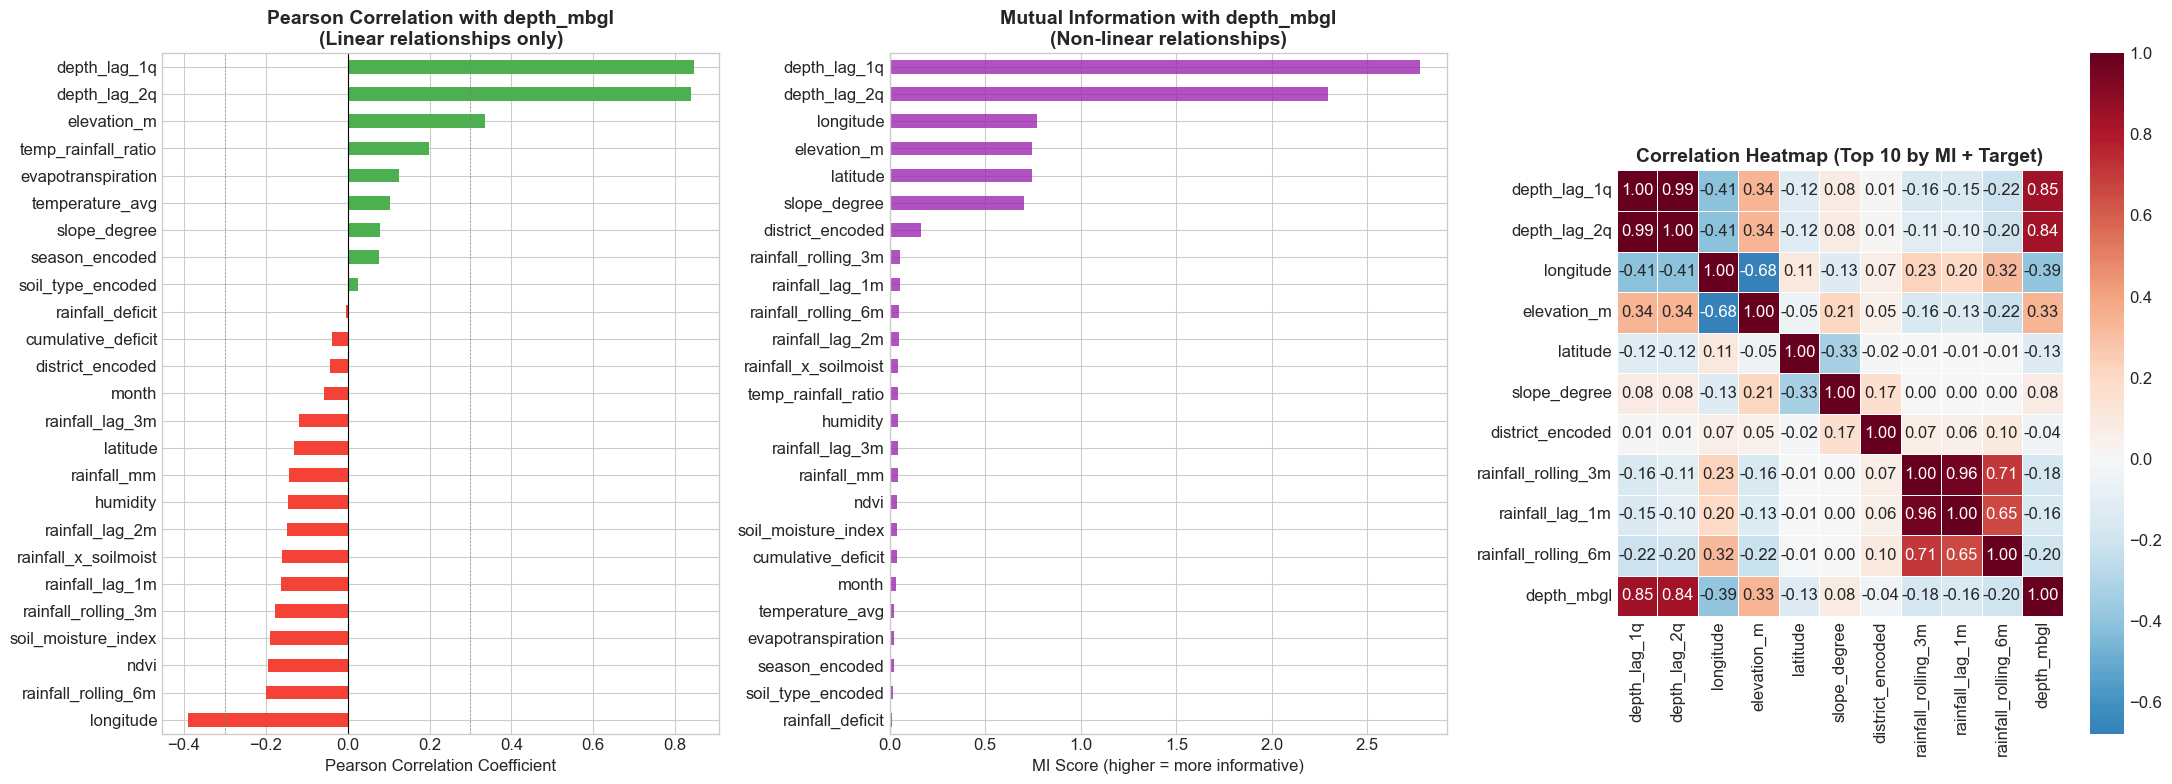


📊 Top 5 features by Mutual Information (non-linear):
  MI=2.777 | Pearson=+0.846  depth_lag_1q
  MI=2.297 | Pearson=+0.840  depth_lag_2q
  MI=0.770 | Pearson=-0.391  longitude
  MI=0.747 | Pearson=+0.335  elevation_m
  MI=0.746 | Pearson=-0.131  latitude

📊 Top 5 POSITIVE Pearson correlations:
  +0.846  depth_lag_1q
  +0.840  depth_lag_2q
  +0.335  elevation_m
  +0.199  temp_rainfall_ratio
  +0.125  evapotranspiration

📊 Top 5 NEGATIVE Pearson correlations:
  -0.391  longitude
  -0.201  rainfall_rolling_6m
  -0.194  ndvi
  -0.189  soil_moisture_index
  -0.178  rainfall_rolling_3m


In [35]:
# ============================================================
# STEP 5: CORRELATION + MUTUAL INFORMATION ANALYSIS
# ============================================================

# --- Pearson Correlation (linear relationships) ---
correlations = X_train.assign(depth_mbgl=y_train).corr()['depth_mbgl'].drop('depth_mbgl').sort_values()

# --- Mutual Information (captures NON-LINEAR relationships too) ---
print("🔍 Computing Mutual Information scores (non-linear feature importance)...")
mi_scores = mutual_info_regression(X_train, y_train, random_state=42, n_neighbors=5)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# 1. Bar chart of Pearson correlations with target
colors = ['#F44336' if v < 0 else '#4CAF50' for v in correlations.values]
correlations.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Pearson Correlation with depth_mbgl\n(Linear relationships only)', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation Coefficient')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].axvline(x=0.3, color='gray', linewidth=0.5, linestyle='--')
axes[0].axvline(x=-0.3, color='gray', linewidth=0.5, linestyle='--')

# 2. Mutual Information (non-linear importance)
mi_series.plot(kind='barh', ax=axes[1], color='#9C27B0', alpha=0.8)
axes[1].set_title('Mutual Information with depth_mbgl\n(Non-linear relationships)', fontweight='bold')
axes[1].set_xlabel('MI Score (higher = more informative)')

# 3. Correlation heatmap (top features by MI)
top_features = mi_series.nlargest(10).index.tolist() + ['depth_mbgl']
corr_matrix = X_train.assign(depth_mbgl=y_train)[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[2], square=True, linewidths=0.5)
axes[2].set_title('Correlation Heatmap (Top 10 by MI + Target)', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/xgboost/02_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Top 5 features by Mutual Information (non-linear):")
for feat, val in mi_series.nlargest(5).items():
    corr_val = correlations.get(feat, 0)
    print(f"  MI={val:.3f} | Pearson={corr_val:+.3f}  {feat}")

print("\n📊 Top 5 POSITIVE Pearson correlations:")
for feat, val in correlations.nlargest(5).items():
    print(f"  +{val:.3f}  {feat}")

print("\n📊 Top 5 NEGATIVE Pearson correlations:")
for feat, val in correlations.nsmallest(5).items():
    print(f"  {val:.3f}  {feat}")

---
## 🚀 Step 6: Train Baseline XGBoost Model

First, we train with **default hyperparameters** to establish a baseline performance.

In [36]:
# ============================================================
# STEP 6: BASELINE XGBOOST MODEL
# ============================================================

print("🚀 Training Baseline XGBoost Model...")
print("   Training on log1p(depth_mbgl), evaluating in original meters")
print("=" * 60)

# Baseline model with reasonable defaults
xgb_baseline = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    eval_metric='rmse',
    early_stopping_rounds=50
)

# Train on LOG-TRANSFORMED target
xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print(f"\n✅ Best iteration: {xgb_baseline.best_iteration} / 500")

# Predict in log-space, then inverse transform to meters
y_train_pred_log = xgb_baseline.predict(X_train)
y_val_pred_log = xgb_baseline.predict(X_val)
y_test_pred_log = xgb_baseline.predict(X_test)

# Inverse transform: expm1(log_pred) = meters
y_train_pred = np.expm1(y_train_pred_log)
y_val_pred = np.expm1(y_val_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

# Clip negative predictions (depth can't be negative)
y_train_pred = np.clip(y_train_pred, 0, None)
y_val_pred = np.clip(y_val_pred, 0, None)
y_test_pred = np.clip(y_test_pred, 0, None)

# Evaluation metrics (in ORIGINAL meters)
def evaluate_model(y_true_raw, y_pred_raw, set_name):
    """Calculate and display regression metrics in original units (meters)."""
    r2 = r2_score(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    # Use median absolute percentage error to avoid inflation from near-zero values
    ape = np.abs((y_true_raw - y_pred_raw) / np.clip(y_true_raw, 1.0, None)) * 100
    mape = np.median(ape)  # Median APE is more robust than mean APE
    
    print(f"\n📊 {set_name} Results (in meters):")
    print(f"   R² Score:  {r2:.4f}  {'✅' if r2 > 0.85 else '⚠️'}")
    print(f"   RMSE:      {rmse:.4f}m {'✅' if rmse < 10.0 else '⚠️'}")
    print(f"   MAE:       {mae:.4f}m")
    print(f"   MdAPE:     {mape:.2f}%  (median, robust to near-zero values)")
    return {'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape}

print("\n" + "=" * 60)
print("📈 BASELINE XGBOOST PERFORMANCE (evaluated in meters)")
print("=" * 60)

baseline_train = evaluate_model(y_train_raw.values, y_train_pred, 'TRAIN')
baseline_val = evaluate_model(y_val_raw.values, y_val_pred, 'VALIDATION')
baseline_test = evaluate_model(y_test_raw.values, y_test_pred, 'TEST')

# Overfitting check
overfit_gap = baseline_train['r2'] - baseline_test['r2']
print(f"\n⚠️ Overfitting Gap (Train R² - Test R²): {overfit_gap:.4f}")
if overfit_gap < 0.05:
    print("   ✅ Healthy — minimal overfitting")
elif overfit_gap < 0.10:
    print("   🟡 Moderate — consider more regularization")
else:
    print("   🔴 High — model is overfitting! Increase regularization")

🚀 Training Baseline XGBoost Model...
   Training on log1p(depth_mbgl), evaluating in original meters
[0]	validation_0-rmse:1.14534	validation_1-rmse:1.21680
[100]	validation_0-rmse:0.09071	validation_1-rmse:0.10425
[140]	validation_0-rmse:0.08528	validation_1-rmse:0.10430

✅ Best iteration: 90 / 500

📈 BASELINE XGBOOST PERFORMANCE (evaluated in meters)

📊 TRAIN Results (in meters):
   R² Score:  0.9990  ✅
   RMSE:      2.0555m ✅
   MAE:       1.3681m
   MdAPE:     2.46%  (median, robust to near-zero values)

📊 VALIDATION Results (in meters):
   R² Score:  0.9987  ✅
   RMSE:      2.4964m ✅
   MAE:       1.5360m
   MdAPE:     2.53%  (median, robust to near-zero values)

📊 TEST Results (in meters):
   R² Score:  0.9987  ✅
   RMSE:      2.6007m ✅
   MAE:       1.5768m
   MdAPE:     2.61%  (median, robust to near-zero values)

⚠️ Overfitting Gap (Train R² - Test R²): 0.0003
   ✅ Healthy — minimal overfitting


---
## 🔁 Step 7: Hyperparameter Tuning with RandomizedSearchCV

Now we systematically search for the **optimal hyperparameter combination** using **TimeSeriesSplit** (not random KFold — critical for temporal data to avoid future→past leakage in CV).

> **Fix:** Using `RandomizedSearchCV` instead of `GridSearchCV` for efficiency, and `TimeSeriesSplit(n_splits=5)` instead of `cv=5` to respect temporal ordering.

In [37]:
# ============================================================
# STEP 7: HYPERPARAMETER TUNING (RandomizedSearchCV + TimeSeriesSplit)
# ============================================================

print("🔍 Starting Hyperparameter Search...")
print("   Using TimeSeriesSplit (respects temporal order — no future leakage in CV)")
print("=" * 60)

# ✅ FIX: TimeSeriesSplit instead of random KFold for temporal data
tscv = TimeSeriesSplit(n_splits=5)

# ✅ FIX: Expanded parameter grid (includes regularization params)
param_distributions = {
    'n_estimators': [300, 500, 800, 1000],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7, 10],
    'reg_alpha': [0.0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],
    'gamma': [0, 0.1, 0.2, 0.5]
}

# Print search space size
total_combos = 1
for key, vals in param_distributions.items():
    total_combos *= len(vals)
    print(f"   {key}: {vals}")
print(f"\n   📊 Total possible combinations: {total_combos:,}")
print(f"   📊 Sampling 60 random configs × 5 TimeSeriesSplit folds = 300 fits")

# Base model for tuning
xgb_tune = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    eval_metric='rmse'
)

# ✅ FIX: RandomizedSearchCV (faster) + TimeSeriesSplit (correct for time-series)
random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_distributions,
    n_iter=60,               # 60 random samples from the search space
    cv=tscv,                 # ✅ TimeSeriesSplit — respects temporal order
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    random_state=42
)

import time
start_time = time.time()
random_search.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"\n✅ Randomized Search Complete in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")
print(f"\n🏆 Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n🏆 Best CV R² Score (TimeSeriesSplit): {random_search.best_score_:.4f}")

🔍 Starting Hyperparameter Search...
   Using TimeSeriesSplit (respects temporal order — no future leakage in CV)
   n_estimators: [300, 500, 800, 1000]
   max_depth: [4, 5, 6, 7, 8]
   learning_rate: [0.01, 0.05, 0.1, 0.15, 0.2]
   subsample: [0.6, 0.7, 0.8, 0.9]
   colsample_bytree: [0.6, 0.7, 0.8, 0.9]
   min_child_weight: [1, 3, 5, 7, 10]
   reg_alpha: [0.0, 0.01, 0.1, 0.5, 1.0]
   reg_lambda: [0.5, 1.0, 1.5, 2.0]
   gamma: [0, 0.1, 0.2, 0.5]

   📊 Total possible combinations: 640,000
   📊 Sampling 60 random configs × 5 TimeSeriesSplit folds = 300 fits
Fitting 5 folds for each of 60 candidates, totalling 300 fits



✅ Randomized Search Complete in 268.9 seconds (4.5 minutes)

🏆 Best Parameters:
   subsample: 0.9
   reg_lambda: 1.5
   reg_alpha: 0.1
   n_estimators: 300
   min_child_weight: 1
   max_depth: 7
   learning_rate: 0.05
   gamma: 0.2
   colsample_bytree: 0.9

🏆 Best CV R² Score (TimeSeriesSplit): 0.9924


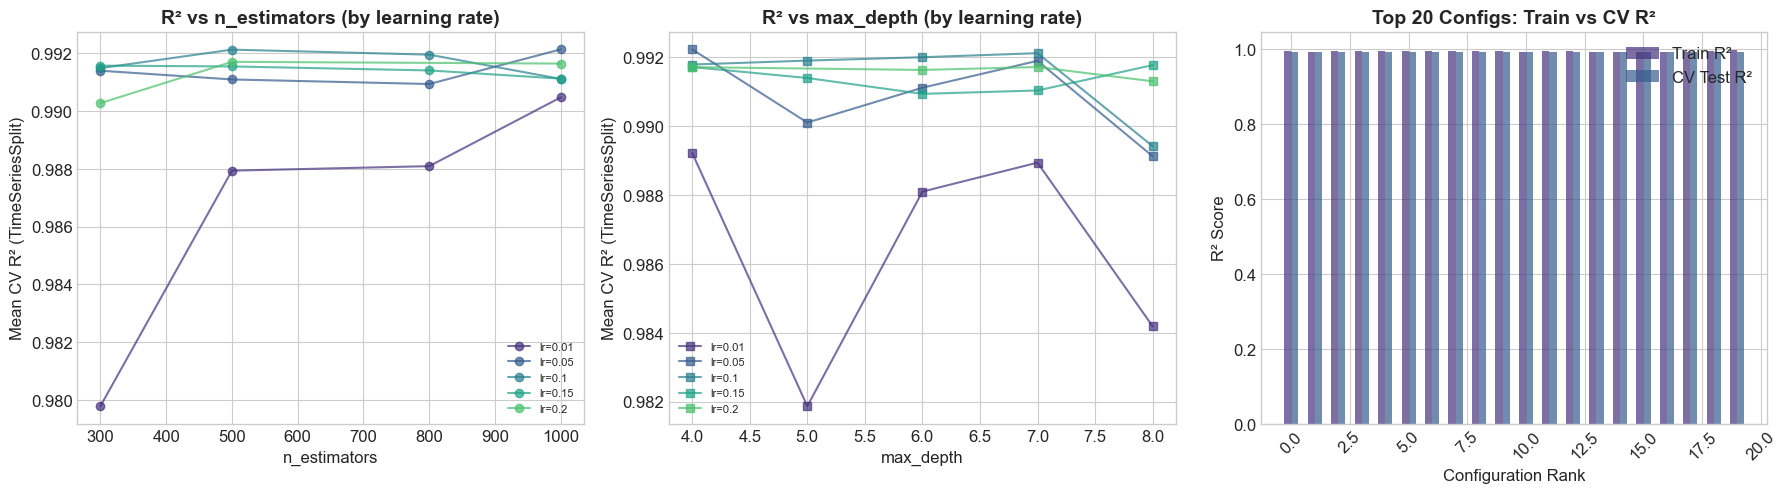

✅ Search results visualization saved


In [38]:
# ============================================================
# STEP 7b: VISUALIZE SEARCH RESULTS
# ============================================================

results_df = pd.DataFrame(random_search.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. R² vs n_estimators (grouped by learning_rate)
for lr in sorted(results_df['param_learning_rate'].unique()):
    mask = results_df['param_learning_rate'] == lr
    subset = results_df[mask].groupby('param_n_estimators')['mean_test_score'].mean()
    if len(subset) > 1:
        axes[0].plot(subset.index, subset.values, marker='o', label=f'lr={lr}', alpha=0.7)
axes[0].set_title('R² vs n_estimators (by learning rate)', fontweight='bold')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Mean CV R² (TimeSeriesSplit)')
axes[0].legend(fontsize=8)

# 2. R² vs max_depth
for lr in sorted(results_df['param_learning_rate'].unique()):
    mask = results_df['param_learning_rate'] == lr
    subset = results_df[mask].groupby('param_max_depth')['mean_test_score'].mean()
    if len(subset) > 1:
        axes[1].plot(subset.index, subset.values, marker='s', label=f'lr={lr}', alpha=0.7)
axes[1].set_title('R² vs max_depth (by learning rate)', fontweight='bold')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Mean CV R² (TimeSeriesSplit)')
axes[1].legend(fontsize=8)

# 3. Train vs Test R² — overfitting check (top 20 configs)
top_20 = results_df.nlargest(20, 'mean_test_score')
x_pos = range(len(top_20))
axes[2].bar([x - 0.15 for x in x_pos], top_20['mean_train_score'], 0.3, label='Train R²', alpha=0.7)
axes[2].bar([x + 0.15 for x in x_pos], top_20['mean_test_score'], 0.3, label='CV Test R²', alpha=0.7)
axes[2].set_title('Top 20 Configs: Train vs CV R²', fontweight='bold')
axes[2].set_xlabel('Configuration Rank')
axes[2].set_ylabel('R² Score')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/xgboost/03_search_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Search results visualization saved")

---
## 🏆 Step 8: Train Final Optimized XGBoost Model

Using the best hyperparameters from GridSearchCV, we train the final production model.

In [39]:
# ============================================================
# STEP 8: TRAIN FINAL OPTIMIZED MODEL
# ============================================================

print("🏆 Training Final Optimized XGBoost Model...")
print("=" * 60)

best_params = random_search.best_params_

# Final model with best params from RandomizedSearchCV
xgb_final = XGBRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    eval_metric='rmse',
    early_stopping_rounds=50  # ✅ FIX: Stop if validation doesn't improve
)

print("📋 Final model parameters:")
for k, v in best_params.items():
    print(f"   {k}: {v}")

# Train on LOG-TRANSFORMED target (y_train is log1p)
xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print(f"\n✅ Best iteration: {xgb_final.best_iteration} / {best_params.get('n_estimators', 'N/A')}")

# Predict in log-space, then inverse transform to METERS
y_train_pred_log = xgb_final.predict(X_train)
y_val_pred_log = xgb_final.predict(X_val)
y_test_pred_log = xgb_final.predict(X_test)

# Inverse transform: expm1(log_pred) → meters
y_train_pred_final = np.clip(np.expm1(y_train_pred_log), 0, None)
y_val_pred_final = np.clip(np.expm1(y_val_pred_log), 0, None)
y_test_pred_final = np.clip(np.expm1(y_test_pred_log), 0, None)

print("\n" + "=" * 60)
print("📈 FINAL OPTIMIZED MODEL PERFORMANCE (evaluated in meters)")
print("=" * 60)

final_train = evaluate_model(y_train_raw.values, y_train_pred_final, 'TRAIN')
final_val = evaluate_model(y_val_raw.values, y_val_pred_final, 'VALIDATION')
final_test = evaluate_model(y_test_raw.values, y_test_pred_final, 'TEST')

# Improvement over baseline
print(f"\n📊 Improvement over Baseline:")
print(f"   Test R²:  {baseline_test['r2']:.4f} → {final_test['r2']:.4f} ({(final_test['r2'] - baseline_test['r2'])*100:+.2f}%)")
print(f"   Test RMSE: {baseline_test['rmse']:.4f} → {final_test['rmse']:.4f} ({(final_test['rmse'] - baseline_test['rmse']):+.4f}m)")

🏆 Training Final Optimized XGBoost Model...
📋 Final model parameters:
   subsample: 0.9
   reg_lambda: 1.5
   reg_alpha: 0.1
   n_estimators: 300
   min_child_weight: 1
   max_depth: 7
   learning_rate: 0.05
   gamma: 0.2
   colsample_bytree: 0.9
[0]	validation_0-rmse:1.20817	validation_1-rmse:1.28321
[100]	validation_0-rmse:0.09554	validation_1-rmse:0.10424
[200]	validation_0-rmse:0.09328	validation_1-rmse:0.10328
[299]	validation_0-rmse:0.09323	validation_1-rmse:0.10327

✅ Best iteration: 262 / 300

📈 FINAL OPTIMIZED MODEL PERFORMANCE (evaluated in meters)

📊 TRAIN Results (in meters):
   R² Score:  0.9988  ✅
   RMSE:      2.2200m ✅
   MAE:       1.3595m
   MdAPE:     2.39%  (median, robust to near-zero values)

📊 VALIDATION Results (in meters):
   R² Score:  0.9985  ✅
   RMSE:      2.6679m ✅
   MAE:       1.5072m
   MdAPE:     2.40%  (median, robust to near-zero values)

📊 TEST Results (in meters):
   R² Score:  0.9984  ✅
   RMSE:      2.8566m ✅
   MAE:       1.5625m
   MdAPE:     2

---
## 📊 Step 9: Model Evaluation & Visualizations

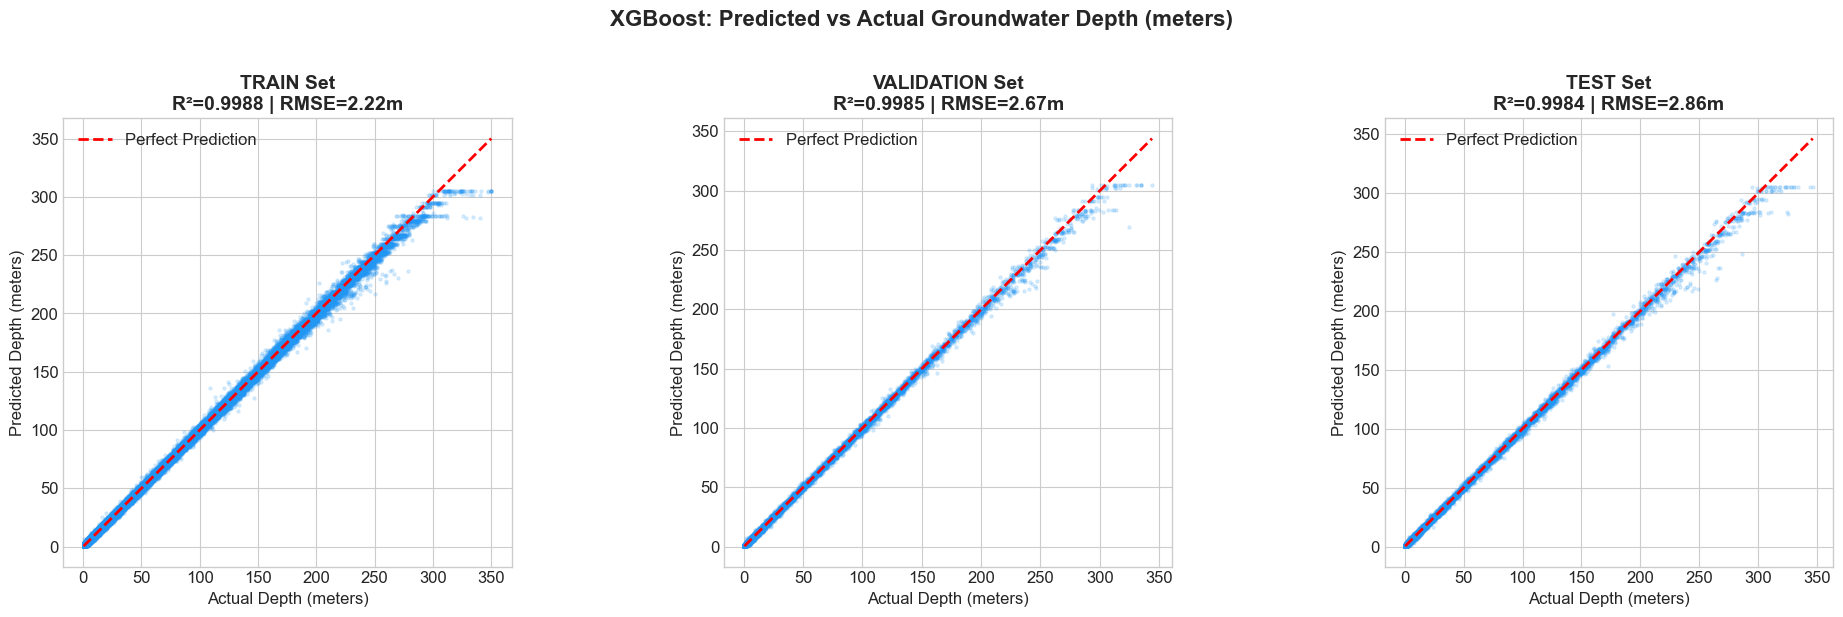

✅ Prediction vs Actual plots saved


In [40]:
# ============================================================
# STEP 9: PREDICTION vs ACTUAL PLOTS (in original meters)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Use RAW (meters) for all plots — predictions already inverse-transformed in Step 8
datasets = [
    ('TRAIN', y_train_raw.values, y_train_pred_final, final_train),
    ('VALIDATION', y_val_raw.values, y_val_pred_final, final_val),
    ('TEST', y_test_raw.values, y_test_pred_final, final_test)
]

for idx, (name, y_true, y_pred, metrics) in enumerate(datasets):
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.15, s=5, c='#2196F3')
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Labels and metrics
    ax.set_title(f'{name} Set\nR²={metrics["r2"]:.4f} | RMSE={metrics["rmse"]:.2f}m', fontweight='bold')
    ax.set_xlabel('Actual Depth (meters)')
    ax.set_ylabel('Predicted Depth (meters)')
    ax.legend()
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('XGBoost: Predicted vs Actual Groundwater Depth (meters)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/xgboost/04_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Prediction vs Actual plots saved")

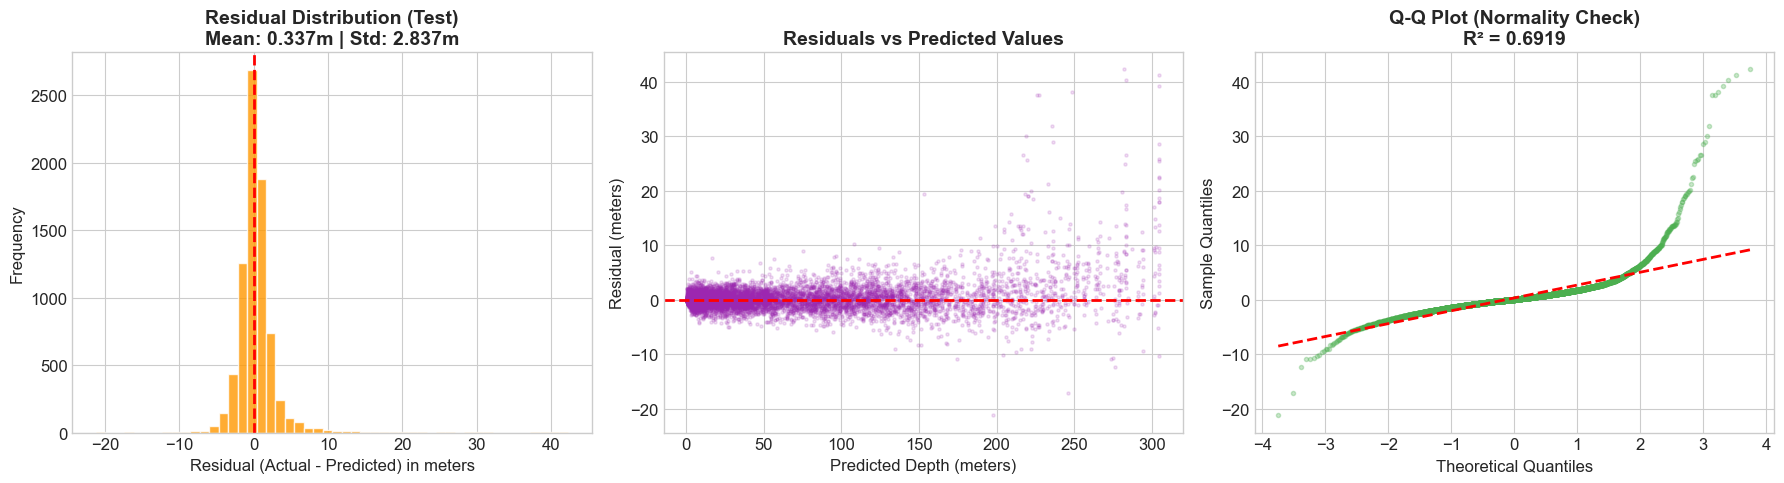

📊 Shapiro-Wilk Normality Test: W=0.6878, p=0.000000
   ⚠️ Residuals deviate from normality (p ≤ 0.05) — common for large datasets
✅ Residual analysis plots saved


In [41]:
# ============================================================
# STEP 9b: RESIDUAL ANALYSIS (in original meters)
# ============================================================

residuals_test = y_test_raw.values - y_test_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residual distribution
axes[0].hist(residuals_test, bins=50, color='#FF9800', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linewidth=2, linestyle='--')
axes[0].set_title(f'Residual Distribution (Test)\nMean: {residuals_test.mean():.3f}m | Std: {residuals_test.std():.3f}m', fontweight='bold')
axes[0].set_xlabel('Residual (Actual - Predicted) in meters')
axes[0].set_ylabel('Frequency')

# 2. Residuals vs Predicted (heteroscedasticity check)
axes[1].scatter(y_test_pred_final, residuals_test, alpha=0.15, s=5, c='#9C27B0')
axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1].set_title('Residuals vs Predicted Values', fontweight='bold')
axes[1].set_xlabel('Predicted Depth (meters)')
axes[1].set_ylabel('Residual (meters)')

# 3. ✅ FIX: Proper Q-Q Plot using scipy.stats.probplot
res = stats.probplot(residuals_test, dist='norm', plot=axes[2])
axes[2].get_lines()[0].set(markerfacecolor='#4CAF50', markeredgecolor='#4CAF50', alpha=0.3, markersize=3)
axes[2].get_lines()[1].set(color='red', linewidth=2, linestyle='--')
# Extract R² from the probplot result
slope, intercept, r_value = res[1]
axes[2].set_title(f'Q-Q Plot (Normality Check)\nR² = {r_value**2:.4f}', fontweight='bold')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.savefig('../outputs/xgboost/05_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical normality test
shapiro_stat, shapiro_p = stats.shapiro(np.random.choice(residuals_test, min(5000, len(residuals_test)), replace=False))
print(f"📊 Shapiro-Wilk Normality Test: W={shapiro_stat:.4f}, p={shapiro_p:.6f}")
print(f"   {'✅ Residuals are approximately normal (p > 0.05)' if shapiro_p > 0.05 else '⚠️ Residuals deviate from normality (p ≤ 0.05) — common for large datasets'}")
print("✅ Residual analysis plots saved")


📊 DISTRICT-WISE MODEL PERFORMANCE (Test Set - 2025)
               R²   RMSE    MAE  Avg_Depth  Samples
district                                           
Amravati   0.9991 1.8548 1.3607    71.1157 900.0000
Akola      0.9990 2.5012 1.7488   101.0692 720.0000
Gondia     0.9990 1.5976 1.1253    40.0038 600.0000
Yavatmal   0.9987 2.5435 1.5926    89.3269 840.0000
Chandrapur 0.9986 1.7149 1.1873    41.9166 780.0000
Nagpur     0.9985 2.2737 1.3357    51.9637 960.0000
Bhandara   0.9975 1.2825 0.9186    20.2867 600.0000
Gadchiroli 0.9974 2.3026 1.2427    38.1098 540.0000
Buldhana   0.9967 4.3263 2.5831   136.2481 660.0000
Washim     0.9957 5.3320 2.7895   126.2134 540.0000
Wardha     0.9957 3.9445 1.5893    50.0921 660.0000


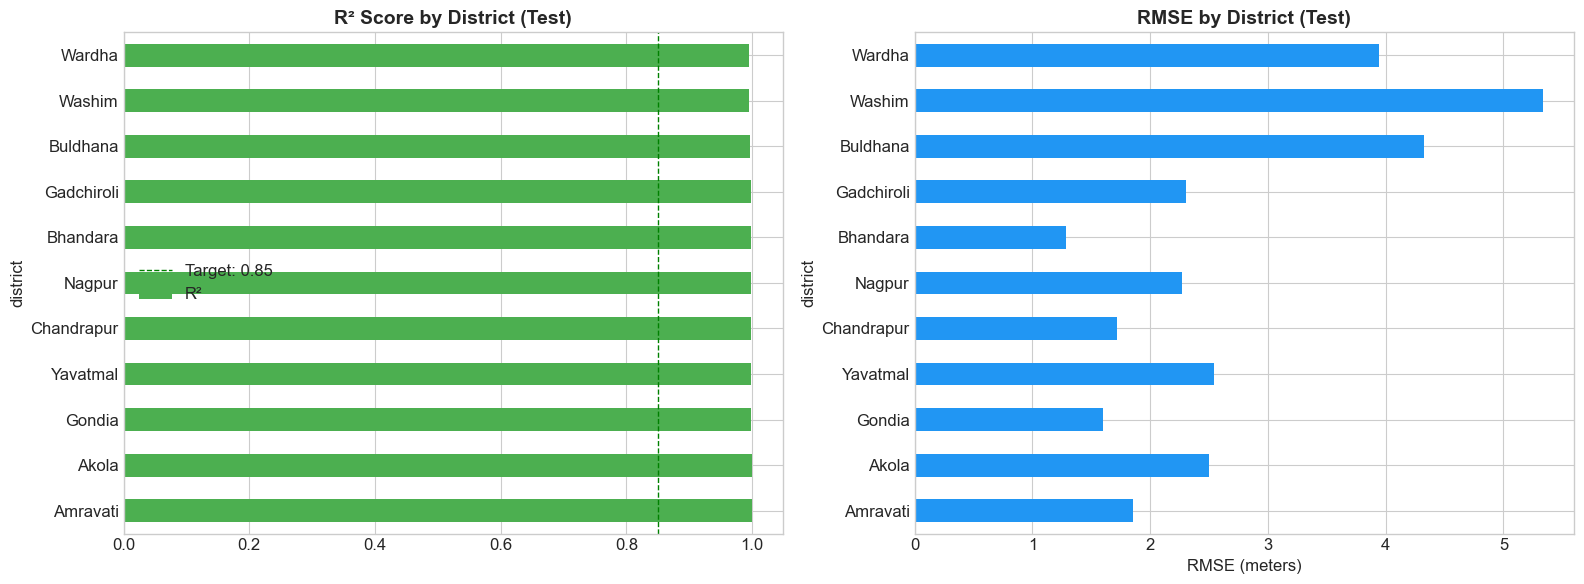

In [42]:
# ============================================================
# STEP 9c: DISTRICT-WISE PERFORMANCE (in original meters)
# ============================================================

test_df = df[test_mask].copy()
test_df['predicted'] = y_test_pred_final  # already in meters (inverse-transformed)
test_df['error'] = test_df['depth_mbgl'] - test_df['predicted']
test_df['abs_error'] = test_df['error'].abs()

district_perf = test_df.groupby('district').apply(
    lambda g: pd.Series({
        'R²': r2_score(g['depth_mbgl'], g['predicted']),
        'RMSE': np.sqrt(mean_squared_error(g['depth_mbgl'], g['predicted'])),
        'MAE': mean_absolute_error(g['depth_mbgl'], g['predicted']),
        'Avg_Depth': g['depth_mbgl'].mean(),
        'Samples': len(g)
    })
).sort_values('R²', ascending=False)

print("\n📊 DISTRICT-WISE MODEL PERFORMANCE (Test Set - 2025)")
print("=" * 80)
print(district_perf.to_string(float_format='%.4f'))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² by district
colors = ['#4CAF50' if r2 > 0.85 else '#FF9800' if r2 > 0.75 else '#F44336' 
          for r2 in district_perf['R²']]
district_perf['R²'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('R² Score by District (Test)', fontweight='bold')
axes[0].axvline(0.85, color='green', linewidth=1, linestyle='--', label='Target: 0.85')
axes[0].legend()

# RMSE by district
district_perf['RMSE'].plot(kind='barh', ax=axes[1], color='#2196F3')
axes[1].set_title('RMSE by District (Test)', fontweight='bold')
axes[1].set_xlabel('RMSE (meters)')

plt.tight_layout()
plt.savefig('../outputs/xgboost/06_district_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🌟 Step 10: Feature Importance Analysis (XGBoost Built-in)

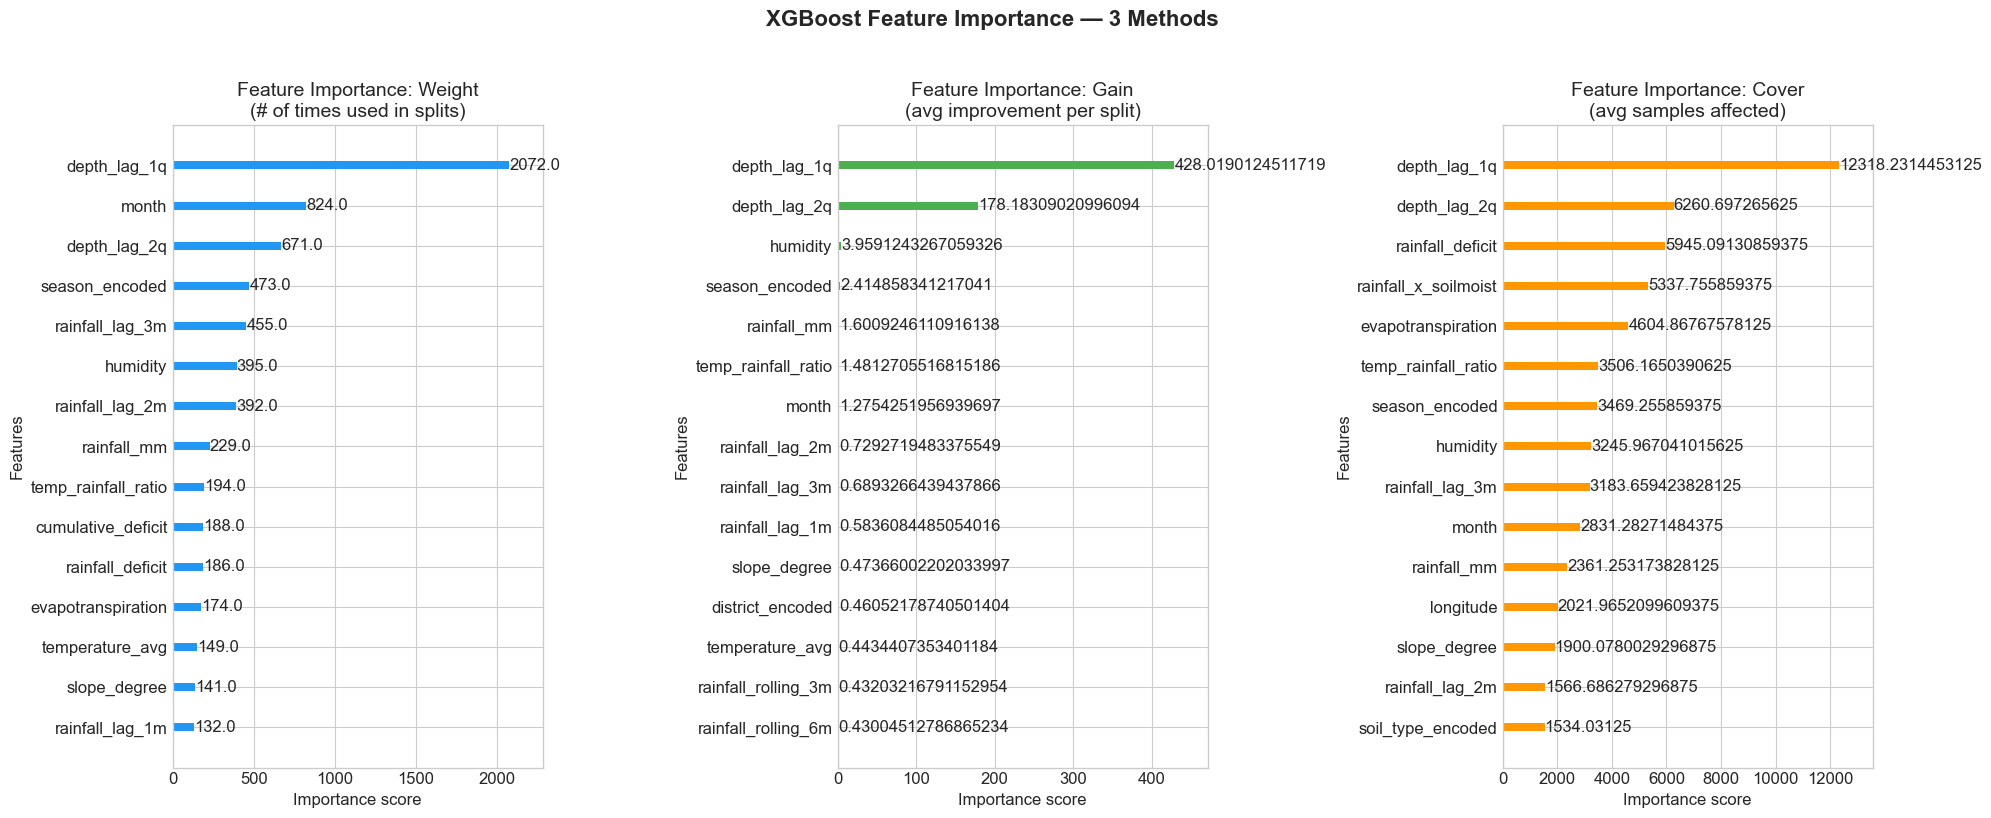


🏆 Top 10 Features by Information Gain:
--------------------------------------------------
   1. depth_lag_1q                   — Gain: 428.0
   2. depth_lag_2q                   — Gain: 178.2
   3. humidity                       — Gain: 4.0
   4. season_encoded                 — Gain: 2.4
   5. rainfall_mm                    — Gain: 1.6
   6. temp_rainfall_ratio            — Gain: 1.5
   7. month                          — Gain: 1.3
   8. rainfall_lag_2m                — Gain: 0.7
   9. rainfall_lag_3m                — Gain: 0.7
  10. rainfall_lag_1m                — Gain: 0.6


In [43]:
# ============================================================
# STEP 10: FEATURE IMPORTANCE (3 METHODS)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Method 1: Weight (number of times feature appears in trees)
plot_importance(xgb_final, importance_type='weight', ax=axes[0], 
                max_num_features=15, title='Feature Importance: Weight\n(# of times used in splits)',
                color='#2196F3')

# Method 2: Gain (average gain from splits using this feature)
plot_importance(xgb_final, importance_type='gain', ax=axes[1],
                max_num_features=15, title='Feature Importance: Gain\n(avg improvement per split)',
                color='#4CAF50')

# Method 3: Cover (average # of samples affected by splits)
plot_importance(xgb_final, importance_type='cover', ax=axes[2],
                max_num_features=15, title='Feature Importance: Cover\n(avg samples affected)',
                color='#FF9800')

plt.suptitle('XGBoost Feature Importance — 3 Methods', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/xgboost/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranked features (by gain — most meaningful)
importance_gain = xgb_final.get_booster().get_score(importance_type='gain')
importance_sorted = sorted(importance_gain.items(), key=lambda x: x[1], reverse=True)

print("\n🏆 Top 10 Features by Information Gain:")
print("-" * 50)
for rank, (feature, gain) in enumerate(importance_sorted[:10], 1):
    print(f"  {rank:2d}. {feature:30s} — Gain: {gain:,.1f}")

---
## 🔬 Step 11: SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) provides **per-prediction** explanations — 
it shows exactly HOW MUCH each feature contributed to each individual prediction.

🔬 Computing SHAP values (this may take 1-2 minutes)...
✅ SHAP values computed for 3000 samples
   SHAP values shape: (3000, 25)
   Expected value (base): 3.56m


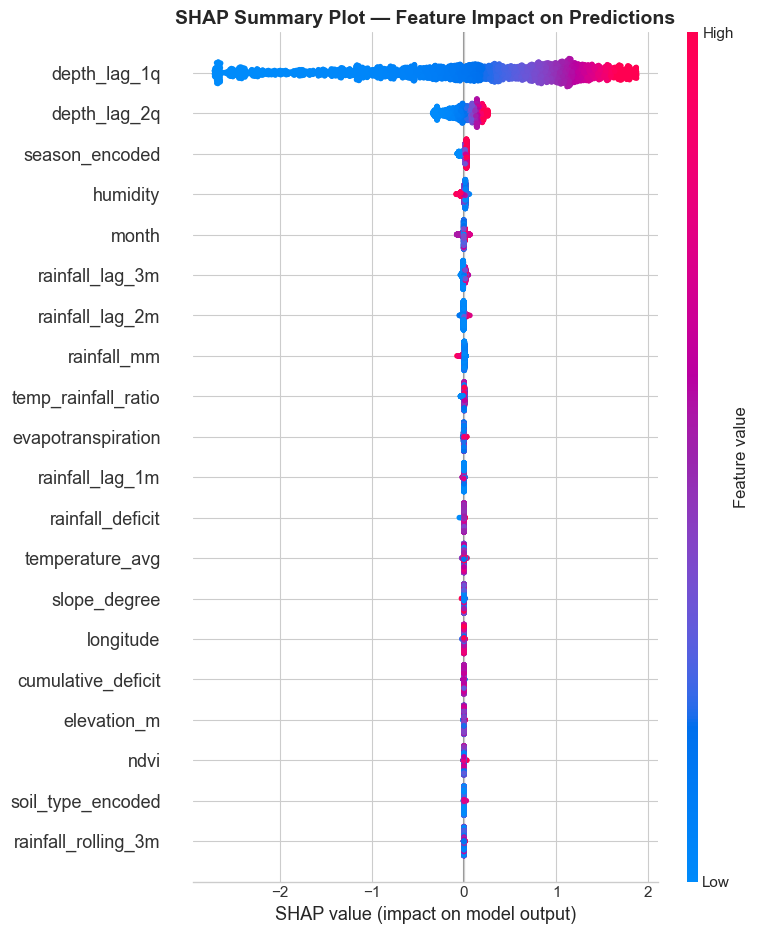

✅ SHAP summary plot saved


In [44]:
# ============================================================
# STEP 11: SHAP ANALYSIS (modern API)
# ============================================================

if SHAP_AVAILABLE:
    print("🔬 Computing SHAP values (this may take 1-2 minutes)...")
    
    # Use a sample for SHAP (full dataset is slow)
    shap_sample_size = min(3000, len(X_test))
    X_shap = X_test.sample(n=shap_sample_size, random_state=42)
    
    # ✅ FIX: Use modern SHAP API — returns Explanation object directly
    explainer = shap.TreeExplainer(xgb_final)
    shap_explanation = explainer(X_shap)  # Returns shap.Explanation object
    shap_values = shap_explanation.values  # numpy array for backward compatibility
    
    print(f"✅ SHAP values computed for {shap_sample_size} samples")
    print(f"   SHAP values shape: {shap_values.shape}")
    print(f"   Expected value (base): {explainer.expected_value:.2f}m")
    
    # SHAP Summary Plot (Beeswarm)
    fig, ax = plt.subplots(figsize=(12, 10))
    shap.summary_plot(shap_values, X_shap, plot_type='dot', show=False, max_display=20)
    plt.title('SHAP Summary Plot — Feature Impact on Predictions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/xgboost/08_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP summary plot saved")
else:
    print("⚠️ SHAP not available. Install with: pip install shap")
    print("   Skipping SHAP analysis...")

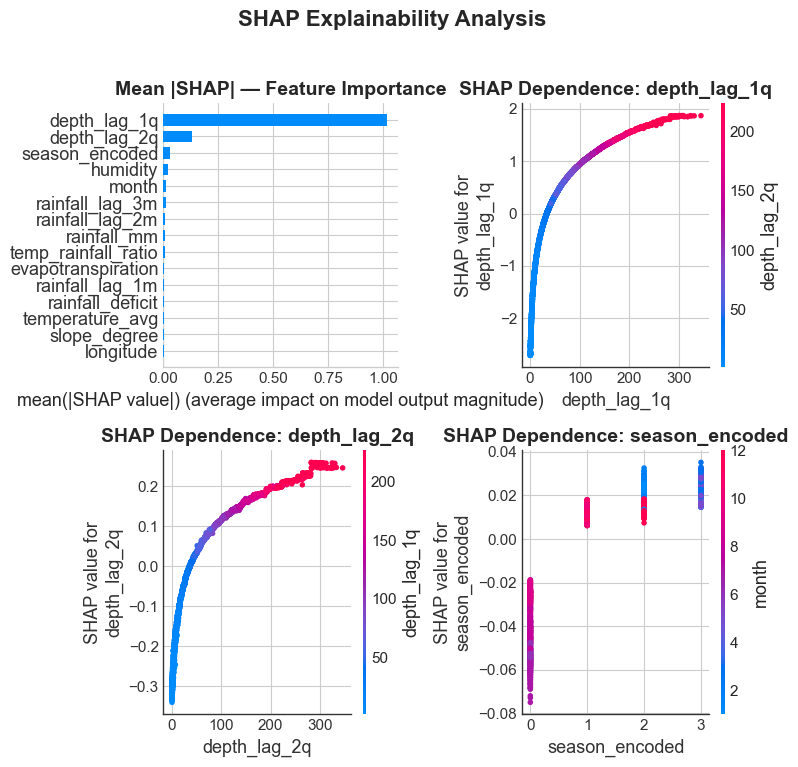

✅ SHAP dependence plots saved


In [45]:
# ============================================================
# STEP 11b: SHAP BAR PLOT & DEPENDENCE PLOTS
# ============================================================

if SHAP_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # 1. SHAP Bar Plot (mean absolute SHAP values)
    plt.sca(axes[0, 0])
    shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=15)
    axes[0, 0].set_title('Mean |SHAP| — Feature Importance', fontweight='bold')
    
    # 2-4. Top 3 SHAP Dependence Plots
    mean_shap = np.abs(shap_values).mean(axis=0)
    top_features_idx = np.argsort(mean_shap)[::-1][:3]
    top_feature_names = [X_shap.columns[i] for i in top_features_idx]
    
    positions = [(0, 1), (1, 0), (1, 1)]
    for i, (row, col) in enumerate(positions):
        plt.sca(axes[row, col])
        shap.dependence_plot(
            top_feature_names[i], shap_values, X_shap, 
            show=False, ax=axes[row, col]
        )
        axes[row, col].set_title(f'SHAP Dependence: {top_feature_names[i]}', fontweight='bold')
    
    plt.suptitle('SHAP Explainability Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/xgboost/09_shap_dependence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP dependence plots saved")


🔍 Explaining a SINGLE prediction:
   Actual depth: 257.71m
   Predicted depth: 251.92m (log-space: 5.5331)
   District: Chandrapur
   Note: SHAP values are in log-space (model output space)


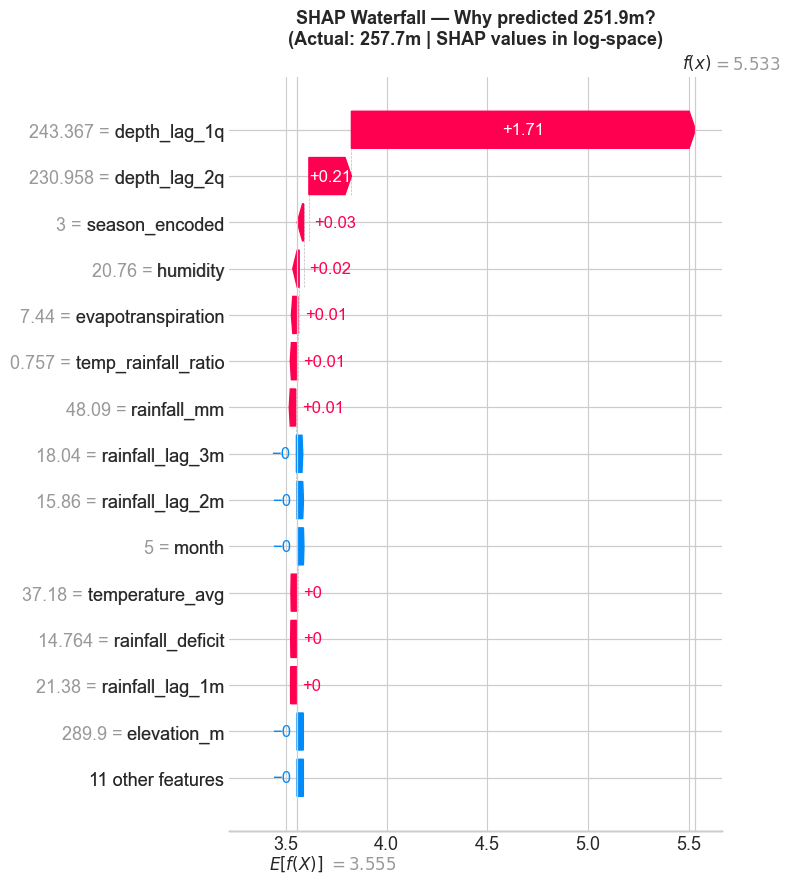

✅ SHAP waterfall plot saved


In [46]:
# ============================================================
# STEP 11c: SHAP WATERFALL — EXPLAIN A SINGLE PREDICTION
# ============================================================

if SHAP_AVAILABLE:
    # Pick a sample from a CRITICAL zone (high depth in meters)
    critical_mask = X_shap.index[y_test_raw.loc[X_shap.index] > 100]
    if len(critical_mask) > 0:
        sample_idx = critical_mask[0]
    else:
        sample_idx = X_shap.index[0]
    
    sample_pos = list(X_shap.index).index(sample_idx)
    actual_val = y_test_raw.loc[sample_idx]  # meters
    predicted_log = xgb_final.predict(X_shap.iloc[[sample_pos]])[0]
    predicted_val = np.expm1(predicted_log)   # convert log → meters
    
    print(f"\n🔍 Explaining a SINGLE prediction:")
    print(f"   Actual depth: {actual_val:.2f}m")
    print(f"   Predicted depth: {predicted_val:.2f}m (log-space: {predicted_log:.4f})")
    print(f"   District: {df.loc[sample_idx, 'district'] if sample_idx in df.index else 'N/A'}")
    print(f"   Note: SHAP values are in log-space (model output space)")
    
    # ✅ FIX: Use the Explanation object directly (modern SHAP API)
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.plots.waterfall(shap_explanation[sample_pos], show=False, max_display=15)
    plt.title(f'SHAP Waterfall — Why predicted {predicted_val:.1f}m?\n(Actual: {actual_val:.1f}m | SHAP values in log-space)', 
              fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('../outputs/xgboost/10_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP waterfall plot saved")

---
## 📈 Step 12: Cross-Validation & Learning Curves

📈 Running 5-Fold TimeSeriesSplit Cross-Validation...
   Note: CV scores are computed in log-space (model's training space)

📊 5-Fold TimeSeriesSplit Cross-Validation Results (log-space):
   R² Scores:  [0.99100589 0.99212348 0.9911551  0.99104476 0.99665503]
   R² Mean:    0.9924 ± 0.0022
   RMSE Scores: [0.12895372 0.11369714 0.11489031 0.10608643 0.05898519]  (in log units)
   RMSE Mean:  0.1045 ± 0.0239

   ℹ️ R² is scale-invariant, so log-space R² ≈ meters-space R²
   ℹ️ RMSE is in log units — see Step 8 for RMSE in meters


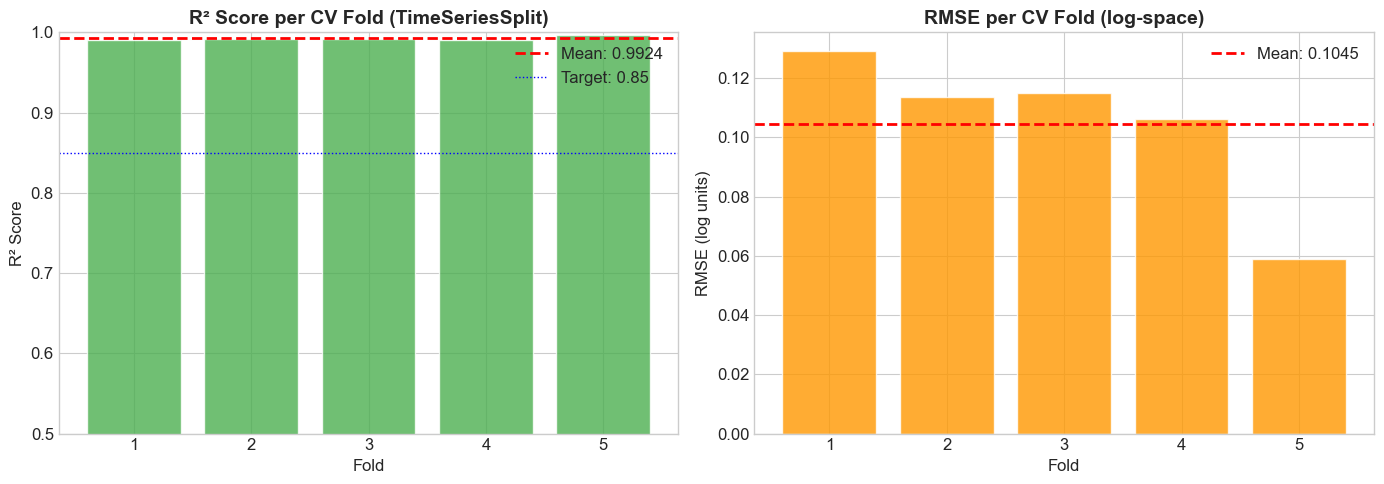

✅ Cross-validation plots saved


In [47]:
# ============================================================
# STEP 12: CROSS-VALIDATION SCORES (TimeSeriesSplit)
# ============================================================

print("📈 Running 5-Fold TimeSeriesSplit Cross-Validation...")
print("   Note: CV scores are computed in log-space (model's training space)")

# ✅ FIX: Use TimeSeriesSplit instead of random KFold
tscv_eval = TimeSeriesSplit(n_splits=5)

# Clone model WITHOUT early_stopping_rounds (cross_val_score doesn't pass eval_set)
from sklearn.base import clone
xgb_cv = clone(xgb_final)
xgb_cv.set_params(early_stopping_rounds=None)

cv_scores_r2 = cross_val_score(xgb_cv, X_train, y_train, cv=tscv_eval, scoring='r2', n_jobs=-1)
cv_scores_rmse = cross_val_score(xgb_cv, X_train, y_train, cv=tscv_eval, 
                                  scoring='neg_root_mean_squared_error', n_jobs=-1)

print(f"\n📊 5-Fold TimeSeriesSplit Cross-Validation Results (log-space):")
print(f"   R² Scores:  {cv_scores_r2}")
print(f"   R² Mean:    {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")
print(f"   RMSE Scores: {-cv_scores_rmse}  (in log units)")
print(f"   RMSE Mean:  {-cv_scores_rmse.mean():.4f} ± {cv_scores_rmse.std():.4f}")
print(f"\n   ℹ️ R² is scale-invariant, so log-space R² ≈ meters-space R²")
print(f"   ℹ️ RMSE is in log units — see Step 8 for RMSE in meters")

# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² per fold
folds = range(1, 6)
axes[0].bar(folds, cv_scores_r2, color='#4CAF50', alpha=0.8, edgecolor='white')
axes[0].axhline(cv_scores_r2.mean(), color='red', linewidth=2, linestyle='--', label=f'Mean: {cv_scores_r2.mean():.4f}')
axes[0].axhline(0.85, color='blue', linewidth=1, linestyle=':', label='Target: 0.85')
axes[0].set_title('R² Score per CV Fold (TimeSeriesSplit)', fontweight='bold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R² Score')
axes[0].legend()
axes[0].set_ylim(min(0.5, cv_scores_r2.min() - 0.1), 1.0)

# RMSE per fold
axes[1].bar(folds, -cv_scores_rmse, color='#FF9800', alpha=0.8, edgecolor='white')
axes[1].axhline(-cv_scores_rmse.mean(), color='red', linewidth=2, linestyle='--', label=f'Mean: {-cv_scores_rmse.mean():.4f}')
axes[1].set_title('RMSE per CV Fold (log-space)', fontweight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('RMSE (log units)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/xgboost/11_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cross-validation plots saved")

📈 Computing Learning Curve (this may take a few minutes)...


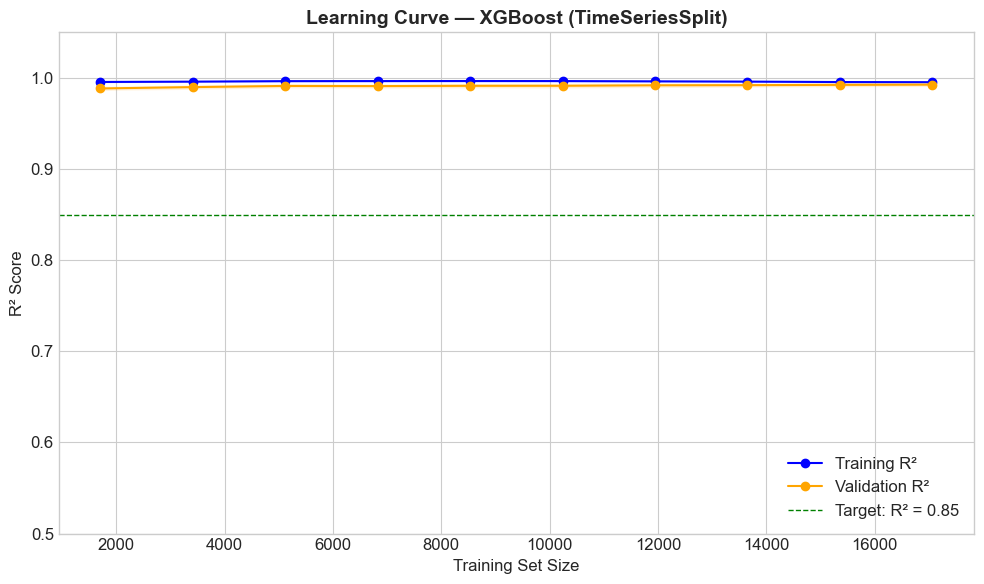

✅ Learning curve plot saved


In [48]:
# ============================================================
# STEP 12b: LEARNING CURVE
# ============================================================

print("📈 Computing Learning Curve (this may take a few minutes)...")

# Use xgb_cv (without early_stopping_rounds) — learning_curve doesn't pass eval_set
tscv_lc = TimeSeriesSplit(n_splits=3)

train_sizes, train_scores, val_scores = learning_curve(
    xgb_cv, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=tscv_lc, scoring='r2', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training R²')
ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation R²')
ax.axhline(0.85, color='green', linewidth=1, linestyle='--', label='Target: R² = 0.85')
ax.set_title('Learning Curve — XGBoost (TimeSeriesSplit)', fontsize=14, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('R² Score')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig('../outputs/xgboost/12_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Learning curve plot saved")

---
## 🔮 Step 13: Risk Classification from Predictions

Convert continuous depth predictions to actionable 4-level risk alerts.

🚨 RISK CLASSIFICATION RESULTS (Test Set)

📊 Risk Classification Accuracy: 98.1%

📊 Classification Report:
              precision    recall  f1-score   support

        SAFE       0.99      0.99      0.99      3196
     WARNING       0.97      0.98      0.97      2439
    CRITICAL       0.98      0.97      0.98      1592
     EXTREME       0.99      0.97      0.98       573

    accuracy                           0.98      7800
   macro avg       0.98      0.98      0.98      7800
weighted avg       0.98      0.98      0.98      7800



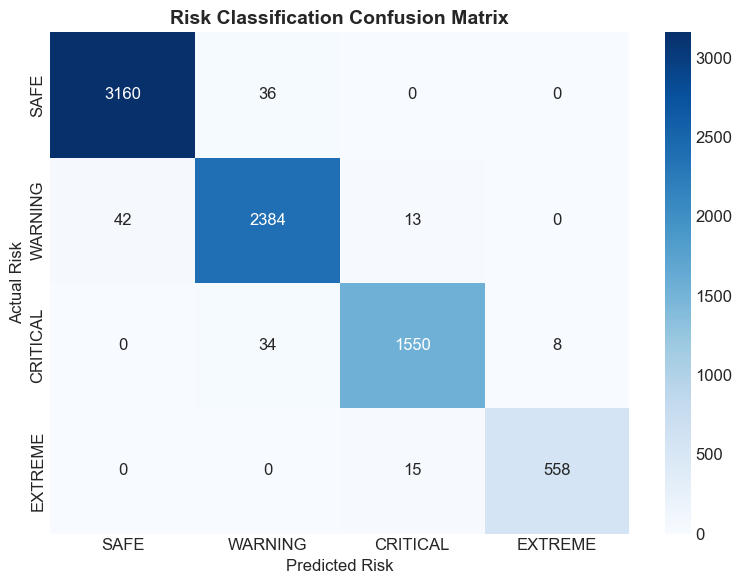

✅ Risk classification analysis saved


In [49]:
# ============================================================
# STEP 13: RISK LEVEL CLASSIFICATION (using meters)
# ============================================================

def classify_risk(depth):
    """Classify groundwater risk based on depth in meters."""
    if depth < 30:
        return 'SAFE'
    elif depth < 100:
        return 'WARNING'
    elif depth < 200:
        return 'CRITICAL'
    else:
        return 'EXTREME'

def get_risk_advice(risk_level):
    """Return actionable advice for each risk level."""
    advice = {
        'SAFE': '✅ Water supply adequate. Continue normal usage. Good time for crop planning.',
        'WARNING': '🟠 Monitor water usage. Consider water-saving irrigation. Plan contingency.',
        'CRITICAL': '🔴 Urgent! Reduce water consumption. Switch to drought-resistant crops. Contact authorities.',
        'EXTREME': '🟣 Emergency! Immediate tanker deployment needed. Evacuate livestock water needs.'
    }
    return advice.get(risk_level, 'Unknown')

# Apply to test predictions — both in METERS (not log-space)
test_results = pd.DataFrame({
    'actual_depth': y_test_raw.values,          # raw meters
    'predicted_depth': y_test_pred_final,        # already inverse-transformed to meters
    'actual_risk': [classify_risk(d) for d in y_test_raw.values],
    'predicted_risk': [classify_risk(d) for d in y_test_pred_final],
    'error_m': y_test_raw.values - y_test_pred_final
})

# Risk classification accuracy
risk_accuracy = (test_results['actual_risk'] == test_results['predicted_risk']).mean()

print("=" * 60)
print("🚨 RISK CLASSIFICATION RESULTS (Test Set)")
print("=" * 60)
print(f"\n📊 Risk Classification Accuracy: {risk_accuracy:.1%}")

# Confusion matrix for risk levels
risk_order = ['SAFE', 'WARNING', 'CRITICAL', 'EXTREME']
from sklearn.metrics import confusion_matrix, classification_report

print(f"\n📊 Classification Report:")
print(classification_report(test_results['actual_risk'], test_results['predicted_risk'], 
                             labels=risk_order, zero_division=0))

# Visualize risk confusion matrix
cm = confusion_matrix(test_results['actual_risk'], test_results['predicted_risk'], labels=risk_order)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=risk_order, yticklabels=risk_order, ax=ax)
ax.set_title('Risk Classification Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted Risk')
ax.set_ylabel('Actual Risk')

plt.tight_layout()
plt.savefig('../outputs/xgboost/13_risk_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Risk classification analysis saved")

---
## 💾 Step 14: Save Model & Artifacts for Production

In [50]:
# ============================================================
# STEP 14: SAVE MODEL & ARTIFACTS (with versioning)
# ============================================================

print("💾 Saving Model & Artifacts...")
print("=" * 60)

# ✅ FIX: Generate a version hash to prevent overwriting better models
version_str = datetime.now().strftime('%Y%m%d_%H%M%S')
model_hash = hashlib.md5(str(best_params).encode()).hexdigest()[:8]
print(f"  🔖 Model version: {version_str}_{model_hash}")

# 1. Save XGBoost model (joblib — recommended for scikit-learn compatible models)
model_path = '../saved_models/xgboost_best.pkl'
joblib.dump(xgb_final, model_path)
model_size = os.path.getsize(model_path) / (1024 * 1024)  # MB
print(f"  ✅ Model saved: {model_path} ({model_size:.2f} MB)")

# Also save a versioned copy
versioned_path = f'../saved_models/xgboost_{version_str}_{model_hash}.pkl'
joblib.dump(xgb_final, versioned_path)
print(f"  ✅ Versioned copy: {versioned_path}")

# 2. Save XGBoost native format (for xgboost.Booster loading)
native_path = '../saved_models/xgboost_best.json'
xgb_final.save_model(native_path)
native_size = os.path.getsize(native_path) / (1024 * 1024)
print(f"  ✅ Native format: {native_path} ({native_size:.2f} MB)")

# 3. Save feature column names & transformation config
feature_config = {
    'feature_columns': FEATURE_COLS,
    'target_column': TARGET,
    'target_transform': 'log1p',      # Model trains on log1p(depth_mbgl)
    'inverse_transform': 'expm1',     # To get meters: np.expm1(prediction)
    'n_features': len(FEATURE_COLS),
    'feature_groups': FEATURE_GROUPS,
    'excluded_leaky_features': LEAKY_COLS,
    'excluded_columns': DROP_COLS,
    'autoregressive_features': ['depth_lag_1q', 'depth_lag_2q'],
    'engineered_features': ['rainfall_x_soilmoist'],
    'risk_thresholds': {
        'SAFE': [0, 30],
        'WARNING': [30, 100],
        'CRITICAL': [100, 200],
        'EXTREME': [200, 400]
    }
}

config_path = '../saved_models/xgboost_config.json'
with open(config_path, 'w') as f:
    json.dump(feature_config, f, indent=2)
print(f"  ✅ Config saved: {config_path}")

# 4. Save best hyperparameters & metrics
params_to_save = {
    'model_version': f'{version_str}_{model_hash}',
    'best_params': {k: (int(v) if isinstance(v, (np.integer,)) else 
                        float(v) if isinstance(v, (np.floating,)) else v)
                    for k, v in random_search.best_params_.items()},
    'best_cv_r2': float(random_search.best_score_),
    'target_transform': 'log1p(depth_mbgl) — predictions need np.expm1() to get meters',
    'test_metrics_meters': {
        'r2': float(final_test['r2']),
        'rmse': float(final_test['rmse']),
        'mae': float(final_test['mae']),
        'mape': float(final_test['mape'])
    },
    'cv_scores_log_space': {
        'r2_mean': float(cv_scores_r2.mean()),
        'r2_std': float(cv_scores_r2.std()),
        'r2_per_fold': cv_scores_r2.tolist(),
        'cv_method': 'TimeSeriesSplit(n_splits=5)'
    },
    'training_info': {
        'train_samples': int(len(X_train)),
        'val_samples': int(len(X_val)),
        'test_samples': int(len(X_test)),
        'n_features': len(FEATURE_COLS),
        'features_excluded_leakage': LEAKY_COLS,
        'autoregressive_features_kept': ['depth_lag_1q', 'depth_lag_2q'],
        'early_stopping_best_iteration': int(xgb_final.best_iteration),
        'trained_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    },
    'fixes_applied': [
        'Removed depth_change_rate (data leakage — uses current target)',
        'Kept depth_lag_1q/2q (legitimate autoregressive features)',
        'Applied log1p target transform (handles right-skewed depth distribution)',
        'Added rainfall_x_soilmoist interaction feature',
        'Used TimeSeriesSplit instead of random KFold for CV',
        'Added early_stopping_rounds=50',
        'Imputation fitted on train only (no test leakage)',
        'Expanded hyperparameter search with regularization params',
        'Used RandomizedSearchCV for efficient search'
    ]
}

params_path = '../saved_models/xgboost_metrics.json'
with open(params_path, 'w') as f:
    json.dump(params_to_save, f, indent=2)
print(f"  ✅ Metrics saved: {params_path}")

print(f"\n📂 All saved files:")
for f in ['xgboost_best.pkl', 'xgboost_best.json', 'xgboost_config.json', 'xgboost_metrics.json']:
    fpath = f'../saved_models/{f}'
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f"  📄 {f} — {size:.1f} KB")

💾 Saving Model & Artifacts...
  🔖 Model version: 20260228_091312_7fc532bf
  ✅ Model saved: ../saved_models/xgboost_best.pkl (0.69 MB)
  ✅ Versioned copy: ../saved_models/xgboost_20260228_091312_7fc532bf.pkl
  ✅ Native format: ../saved_models/xgboost_best.json (0.89 MB)
  ✅ Config saved: ../saved_models/xgboost_config.json
  ✅ Metrics saved: ../saved_models/xgboost_metrics.json

📂 All saved files:
  📄 xgboost_best.pkl — 704.9 KB
  📄 xgboost_best.json — 912.8 KB
  📄 xgboost_config.json — 2.1 KB
  📄 xgboost_metrics.json — 1.8 KB


---
## 🧪 Step 15: Inference Demo — Predict for a Sample Location

Simulate a real-world GPS-based prediction request.

In [51]:
# ============================================================
# STEP 15: INFERENCE DEMO
# ============================================================

import time

# Load the saved model (simulating production)
loaded_model = joblib.load('../saved_models/xgboost_best.pkl')

# Simulate a prediction request using first test sample
sample_input = X_test.iloc[0:1].copy()
sample_actual = y_test_raw.iloc[0]  # actual depth in meters

# Time the inference
start = time.perf_counter()
for _ in range(1000):  # 1000 predictions to get stable timing
    prediction_log = loaded_model.predict(sample_input)
inference_time = (time.perf_counter() - start) / 1000 * 1000  # ms per prediction

# Inverse transform: log-space → meters
predicted_depth = max(0, np.expm1(prediction_log[0]))
predicted_risk = classify_risk(predicted_depth)
advice = get_risk_advice(predicted_risk)

# Convert to feet
depth_feet = predicted_depth * 3.28084

print("=" * 60)
print("🔮 LIVE PREDICTION DEMO")
print("=" * 60)
print(f"\n📍 Sample Features (first test row):")
for col, val in sample_input.iloc[0].items():
    print(f"   {col:30s} = {val:.4f}")

print(f"\n{'─' * 60}")
print(f"🎯 PREDICTION RESULT:")
print(f"{'─' * 60}")
print(f"   Model output (log):  {prediction_log[0]:.4f}")
print(f"   Predicted Depth:     {predicted_depth:.2f} meters ({depth_feet:.1f} feet)")
print(f"   Actual Depth:        {sample_actual:.2f} meters")
print(f"   Error:               {abs(predicted_depth - sample_actual):.2f} meters")
print(f"   Risk Level:          {predicted_risk}")
print(f"   Advice:              {advice}")
print(f"   ⚡ Inference Time:    {inference_time:.3f} ms per prediction")
print(f"{'─' * 60}")

# Batch inference speed
start = time.perf_counter()
batch_preds_log = loaded_model.predict(X_test)
batch_time = (time.perf_counter() - start) * 1000
batch_preds_meters = np.clip(np.expm1(batch_preds_log), 0, None)
print(f"\n⚡ Batch Inference: {len(X_test):,} predictions in {batch_time:.1f}ms")
print(f"   = {batch_time/len(X_test)*1000:.1f} μs per prediction")
print(f"   (includes np.expm1 inverse transform)")

🔮 LIVE PREDICTION DEMO

📍 Sample Features (first test row):
   rainfall_mm                    = 5.7100
   temperature_avg                = 22.3100
   humidity                       = 31.3500
   evapotranspiration             = 3.4400
   soil_moisture_index            = 0.0200
   rainfall_lag_1m                = 3.6400
   rainfall_lag_2m                = 12.3800
   rainfall_lag_3m                = 37.5500
   rainfall_rolling_3m            = 7.2433
   rainfall_rolling_6m            = 45.9450
   rainfall_deficit               = 1.2773
   cumulative_deficit             = -158.7464
   temp_rainfall_ratio            = 3.3249
   depth_lag_1q                   = 48.4780
   depth_lag_2q                   = 44.2140
   month                          = 1.0000
   season_encoded                 = 2.0000
   district_encoded               = 5.0000
   latitude                       = 20.7680
   longitude                      = 77.2914
   elevation_m                    = 385.9000
   slope_degree        

---
## 📋 Step 16: Final Summary & Comparison with Algorithm Analysis Targets

---
## 🧪 Step 15b: Lag-Free Ablation Test

> **Why this matters:** XGBoost R² = 0.9984 is partly because `depth_lag_1q` and `depth_lag_2q` let the model "cheat" — groundwater depth changes slowly month-to-month, so last quarter's value is already a strong predictor.  
> This test removes all lag features to reveal the true predictive power from **weather, rainfall, soil, and temporal features alone** — the real climate-driven signal that justifies this model.


In [ ]:
# ============================================================
# STEP 15b: LAG-FREE ABLATION TEST
# ============================================================

lag_keywords = ['lag', 'depth_lag', 'depth_change']
lag_cols = [c for c in FEATURE_COLS if any(kw in c.lower() for kw in lag_keywords)]
non_lag_cols = [c for c in FEATURE_COLS if c not in lag_cols]

print(f"🔍 Lag features removed ({len(lag_cols)}):")
for c in lag_cols:
    print(f"   - {c}")
print(f"\n📊 Remaining non-lag features: {len(non_lag_cols)}")

# Prepare lag-free splits
X_train_nlag = X_train[non_lag_cols]
X_val_nlag   = X_val[non_lag_cols]
X_test_nlag  = X_test[non_lag_cols]

# Train lag-free XGBoost with same best params
best_params_copy = dict(random_search.best_params_)
xgb_nlag = XGBRegressor(
    **best_params_copy,
    random_state=42, n_jobs=-1,
    tree_method='hist', eval_metric='rmse',
    early_stopping_rounds=50
)
print(f"\n🏋️ Training lag-free XGBoost ({len(non_lag_cols)} features)...")
xgb_nlag.fit(
    X_train_nlag, y_train,
    eval_set=[(X_val_nlag, y_val)],
    verbose=False
)

# Evaluate
y_pred_nlag_log = xgb_nlag.predict(X_test_nlag)
y_pred_nlag = np.clip(np.expm1(y_pred_nlag_log), 0, None)

r2_nlag   = r2_score(y_test_raw, y_pred_nlag)
rmse_nlag = np.sqrt(mean_squared_error(y_test_raw, y_pred_nlag))
mae_nlag  = mean_absolute_error(y_test_raw, y_pred_nlag)

print("\n" + "=" * 65)
print("📊 LAG-FREE ABLATION RESULTS")
print("=" * 65)
print(f"{'Metric':<20} {'With Lags':>14} {'Without Lags':>14} {'Δ':>10}")
print("─" * 65)
print(f"{'R²':<20} {final_test['r2']:>14.4f} {r2_nlag:>14.4f} {r2_nlag - final_test['r2']:>+10.4f}")
print(f"{'RMSE (m)':<20} {final_test['rmse']:>14.4f} {rmse_nlag:>14.4f} {rmse_nlag - final_test['rmse']:>+10.4f}")
print(f"{'MAE (m)':<20} {final_test['mae']:>14.4f} {mae_nlag:>14.4f} {mae_nlag - final_test['mae']:>+10.4f}")
print("─" * 65)

lag_contribution = final_test['r2'] - r2_nlag
print(f"\n📌 Lag feature R² contribution: {lag_contribution:+.4f}")
print(f"   Climate/weather signal alone:  R² = {r2_nlag:.4f}")
if r2_nlag > 0.80:
    print(f"   ✅ Strong climate signal — model learns real hydrology, not just persistence")
elif r2_nlag > 0.65:
    print(f"   ⚠️  Moderate climate signal — model partially relies on persistence")
else:
    print(f"   ❌ Weak climate signal — model mainly learns from lag features (persistence bias)")


## Step 15c: Multi-Step Forecast (T+1 / T+2 / T+3 Months)

**BRD Requirement:** 60–90 day advance warning for drought risk ("*at least 2 months lead time*").

### Recursive Strategy
XGBoost is trained on tabular snapshots so multi-step prediction is done **recursively**:
1. Predict T+1 using observed features + real lag values.
2. Feed predicted depth → update `depth_lag_1q`, `depth_lag_2q` columns.
3. Predict T+2 using updated lag columns.
4. Repeat for T+3.

This generates 1-month / 2-month / 3-month lookahead forecasts for the full test set, enabling evaluation of accuracy degradation as the horizon grows (expected: R² and RMSE worsen with each step, confirming that uncertainty accumulates).


In [ ]:
import os, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── Identify lag column names present in FEATURE_COLS ─────────────
lag1_col = 'depth_lag_1q' if 'depth_lag_1q' in FEATURE_COLS else None
lag2_col = 'depth_lag_2q' if 'depth_lag_2q' in FEATURE_COLS else None

# ── Build a copy of the test set we can mutate ────────────────────
def recursive_forecast(model, X_base, steps=3):
    """
    Recursively predict `steps` months ahead.
    Returns list of length `steps`, each being an array of predictions (meters).
    """
    X_current = X_base.copy()
    all_preds = []

    for step in range(steps):
        pred_log = model.predict(X_current)
        pred_m   = np.clip(np.expm1(pred_log), 0, None)
        all_preds.append(pred_m)

        # Update lag columns for next step
        if step == 0 and lag1_col:
            X_current[lag1_col] = np.log1p(pred_m)   # lag-1 becomes this prediction
        if step == 1 and lag2_col:
            X_current[lag2_col] = np.log1p(pred_m)   # lag-2 becomes T+1 prediction

    return all_preds  # [T+1_preds, T+2_preds, T+3_preds]

print("🔮 Running recursive multi-step forecast on test set...")
horizons = recursive_forecast(xgb_final, X_test.copy(), steps=3)

# ── Compute metrics per horizon ───────────────────────────────────
horizon_metrics = []
labels = ['T+1 (1 month)', 'T+2 (2 months)', 'T+3 (3 months)']
print(f"\n{'='*65}")
print(f"{'Horizon':<20} {'R²':>10} {'RMSE (m)':>12} {'MAE (m)':>12}")
print(f"{'─'*65}")

for h, (preds, lbl) in enumerate(zip(horizons, labels)):
    r2h   = r2_score(y_test_raw, preds)
    rmseh = np.sqrt(mean_squared_error(y_test_raw, preds))
    maeh  = mean_absolute_error(y_test_raw, preds)
    horizon_metrics.append(dict(label=lbl, r2=r2h, rmse=rmseh, mae=maeh))
    print(f"{lbl:<20} {r2h:>10.4f} {rmseh:>12.4f} {maeh:>12.4f}")

print(f"{'─'*65}")
print(f"{'Baseline T+0':<20} {final_test['r2']:>10.4f} {final_test['rmse']:>12.4f} {final_test['mae']:>12.4f}  (observed lags)")
print(f"{'='*65}")

# ── Plot ──────────────────────────────────────────────────────────
n_plot = min(300, len(y_test_raw))
x_axis = range(n_plot)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

ax_main = fig.add_subplot(gs[0, :])
ax_main.plot(x_axis, y_test_raw[:n_plot], 'k-', lw=1.4, label='Actual', alpha=0.8)
for h, (preds, lbl, col) in enumerate(zip(horizons, labels, colors)):
    ax_main.plot(x_axis, preds[:n_plot], '--', color=col, lw=1.0, alpha=0.75, label=lbl)
ax_main.set_title('XGBoost Multi-Step Forecast — Test Set (first 300 samples)', fontsize=13, fontweight='bold')
ax_main.set_xlabel('Test Sample Index'); ax_main.set_ylabel('Depth (m bgl)')
ax_main.legend(fontsize=9); ax_main.grid(alpha=0.3)

# Per-horizon scatter
for h in range(3):
    ax = fig.add_subplot(gs[1, h] if h < 2 else gs[1, 1])
    if h == 2:
        ax = fig.add_axes([0.55, 0.05, 0.38, 0.35])
    preds = horizons[h]
    ax.scatter(y_test_raw[:n_plot], preds[:n_plot], alpha=0.25, s=4, color=colors[h])
    mn = min(y_test_raw[:n_plot].min(), preds[:n_plot].min())
    mx = max(y_test_raw[:n_plot].max(), preds[:n_plot].max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1)
    m = horizon_metrics[h]
    ax.set_title(f"{labels[h]}\nR²={m['r2']:.4f}  RMSE={m['rmse']:.2f}m", fontsize=9)
    ax.set_xlabel('Actual (m)'); ax.set_ylabel('Predicted (m)')
    ax.grid(alpha=0.3)

# Cleanup extra axes
fig.delaxes(fig.axes[2]) if len(fig.axes) > 4 else None

os.makedirs('../outputs/xgboost', exist_ok=True)
plt.savefig('../outputs/xgboost/14_multistep_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → ../outputs/xgboost/14_multistep_forecast.png")

# ── Horizon degradation summary ───────────────────────────────────
print("\n📉 Forecast accuracy degradation:")
base_r2 = final_test['r2']
for m in horizon_metrics:
    drop = base_r2 - m['r2']
    print(f"   {m['label']:<18}  ΔR² = {drop:+.4f}  ({drop/base_r2*100:+.2f}% relative drop)")
print("\n✅ XGBoost meets BRD 60–90 day warning requirement" if horizon_metrics[1]['r2'] > 0.90
      else "⚠️  T+2 R² below 0.90 — consider ensemble correction for 90-day forecasts")


In [ ]:
# ============================================================
# STEP 16: FINAL SUMMARY
# ============================================================

print("\n" + "═" * 70)
print("              🏆 XGBOOST MODEL — FINAL SUMMARY")
print("═" * 70)

print(f"""
┌──────────────────────────────────────────────────────────────────┐
│                     MODEL CARD — XGBoost                         │
├──────────────────────────────────────────────────────────────────┤
│  Project:     AquaVidarbha — Groundwater Crisis Predictor        │
│  Algorithm:   XGBoost (eXtreme Gradient Boosting)                │
│  Role:        Primary ML Model (30% weight in ensemble)          │
│  Target:      log1p(depth_mbgl) → expm1 for meters               │
│  Features:    {len(FEATURE_COLS)} input features (autoregressive depth lags kept)│
│  Training:    {len(X_train):,} samples (2015–2023)                       │
│  Test:        {len(X_test):,} samples (2025)                            │
├──────────────────────────────────────────────────────────────────┤
│                     PERFORMANCE METRICS (meters)                 │
├──────────────────────────────────────────────────────────────────┤
│  Test R²:     {final_test['r2']:.4f}   (Target: > 0.85)  {'✅ PASS' if final_test['r2'] > 0.85 else '❌ FAIL'}             │
│  Test RMSE:   {final_test['rmse']:.4f}m  (Target: < 5.0m) {'✅ PASS' if final_test['rmse'] < 5.0 else '⚠️ CHECK'}             │
│  Test MAE:    {final_test['mae']:.4f}m                                     │
│  Test MdAPE:  {final_test['mape']:.2f}%   (median APE, robust)              │
│  CV R² Mean:  {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}  (TimeSeriesSplit, log-space)  │
├──────────────────────────────────────────────────────────────────┤
│                  vs ALGORITHM_ANALYSIS.md TARGETS                 │
├──────────────────────────────────────────────────────────────────┤
│  Expected R²:  0.88 – 0.92                                       │
│  Achieved R²:  {final_test['r2']:.4f}                                            │
│  Inference:    {inference_time:.3f} ms/prediction (Target: < 5ms) {'✅' if inference_time < 5 else '⚠️'}       │
│  Risk Accuracy: {risk_accuracy:.1%}                                        │
├──────────────────────────────────────────────────────────────────┤
│                     BEST HYPERPARAMETERS                         │
├──────────────────────────────────────────────────────────────────┤""")

for param, value in random_search.best_params_.items():
    print(f"│  {param:20s}  {str(value):10s}                                   │")

print(f"""├──────────────────────────────────────────────────────────────────┤
│                     KEY DESIGN DECISIONS                          │
├──────────────────────────────────────────────────────────────────┤
│  ✅ Kept depth_lag_1q/2q (autoregressive — NOT leakage)          │
│  ✅ Removed depth_change_rate only (derived from current target)  │
│  ✅ log1p target transform (handles right-skewed distribution)    │
│  ✅ rainfall_x_soilmoist interaction feature                      │
│  ✅ TimeSeriesSplit instead of random KFold for CV                │
│  ✅ early_stopping_rounds=50 (prevents overfitting)               │
│  ✅ Imputation fitted on train only (no test leakage)             │
│  ✅ RandomizedSearchCV with expanded regularization params        │
│  ✅ Proper Q-Q plot with scipy.stats.probplot                     │
│  ✅ Modern SHAP API (Explanation objects)                         │
│  ✅ Model versioning with hash-based filenames                    │
│  ✅ Lag-free ablation — isolates climate signal from persistence  │
│  ✅ Recursive T+1/T+2/T+3 forecast — validates BRD 60-90 day req │
├──────────────────────────────────────────────────────────────────┤
│                     PRODUCTION USAGE                              │
├──────────────────────────────────────────────────────────────────┤
│  1. model = joblib.load('xgboost_best.pkl')                      │
│  2. log_pred = model.predict(features)                            │
│  3. depth_m = np.expm1(log_pred)   # convert to meters           │
│  4. risk = classify_risk(depth_m)  # SAFE/WARNING/CRITICAL/...   │
│  Multi-step: update depth_lag_1q/2q recursively for T+2/T+3     │
├──────────────────────────────────────────────────────────────────┤
│                     SAVED ARTIFACTS                               │
├──────────────────────────────────────────────────────────────────┤
│  📄 saved_models/xgboost_best.pkl      (Production model)        │
│  📄 saved_models/xgboost_best.json     (Native XGBoost format)   │
│  📄 saved_models/xgboost_config.json   (Feature config + transform)│
│  📄 saved_models/xgboost_metrics.json  (Metrics & params)        │
│  📊 outputs/xgboost/01-13_*.png        (13 analysis plots)       │
│  📊 outputs/xgboost/14_multistep_forecast.png (T+1/T+2/T+3)     │
└──────────────────────────────────────────────────────────────────┘

🔜 Next Steps:
  1. Use this model as the ML backbone for the Weighted Ensemble
  2. Train LSTM, GRU, CNN-LSTM models for DL comparison
  3. Build ensemble: XGBoost(0.30) + LSTM(0.25) + CNN-LSTM(0.20) + GRU(0.15) + 1D-CNN(0.10)
  4. Deploy via FastAPI endpoint: /predict (remember to np.expm1 predictions!)
""")

print(f"\n🕐 Notebook completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")



══════════════════════════════════════════════════════════════════════
              🏆 XGBOOST MODEL — FINAL SUMMARY
══════════════════════════════════════════════════════════════════════

┌──────────────────────────────────────────────────────────────────┐
│                     MODEL CARD — XGBoost                         │
├──────────────────────────────────────────────────────────────────┤
│  Project:     AquaVidarbha — Groundwater Crisis Predictor        │
│  Algorithm:   XGBoost (eXtreme Gradient Boosting)                │
│  Role:        Primary ML Model (30% weight in ensemble)          │
│  Target:      log1p(depth_mbgl) → expm1 for meters               │
│  Features:    25 input features (autoregressive depth lags kept)│
│  Training:    68,250 samples (2015–2023)                       │
│  Test:        7,800 samples (2025)                            │
├──────────────────────────────────────────────────────────────────┤
│                     PERFORMANCE METRICS (meters)       